# ESDA2 Individual Project Part 2 – River and Rainfall Data [50 marks]

This second part of the individual project presents you with some data and a set of questions, but you will need to use your data analysis skills and knowledge to figure out how to work with the data, what plots to make, and what calculations to do to explore the questions. It is split into three sections, Fundamentals, Core, or Advanced, and the marks allocated to each section are given in square brackets. This part of the project is weighted approximately 40% Fundamentals, 25% Core, and 35% Advanced; Part 1 is more heavily weighted towards Fundamentals, with Core split equally between them.

**This assignment should be done entirely individually.** You may use the Jupyternaut AI, python package manuals, and other online resources (not including asking people online or other online AI) to help with your coding, but make sure your code is clearly commented showing what each section does. You should be able to explain what each line does if asked. 

In this assessment we want to see the process you go through for data analysis – a significant portion of the marks are allocated to how you explain the steps you took, why you took them, and your interpretation of the results. **Correct code on its own is not sufficient.** That also means that if you can explain what you want to do and why, you can receive partial credit for that part of the data analysis, even without being able to code it up. 

If you cannot get part of the code to work, you can maximise your partial credit by explaining what you are trying to do, your understanding of what is not working, and what you have tried to fix it.

If you cannot get one of the files to load, please ask Lara. Depending on the amount of help required, this will reduce the marks you can get for the actual file import, but we do not want you unable to even attempt large sections of the assignment due to initial file problems.

In [3]:
# Load the libraries you need using the standard aliases. Add to this as you work through the notebook.
#Also set up a variable with the absolute path to the shared data directory.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
from scipy import stats

# set path to shared data directory
data_path = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'data', 'RiverWearData') + os.sep 
print(data_path)

c:\Users\JoelM\OneDrive - University of Edinburgh\Year 2\Earth Science Data Analysis 2\ESDA2_Project2\data\RiverWearData\


## Section 1 [Fundamentals, 20 marks]: The River Wear

In this section of the notebook, we will be looking at river levels along the River Wear in County Durham.

Data: The folder `RiverWearData` in the shared data directory contains daily flow data for five stations along the River Wear obtained from [https://nrfa.ceh.ac.uk/data/search](https://nrfa.ceh.ac.uk/data/search). 

Questions:
- Do some initial data exploration to familiarise yourself with the data. 
- Can you correlate peaks in river level between the stations? What is the typical time delay between stations?
- River levels are typically split into seven levels: exceptionally low, notably low, below normal, normal, above normal, notably high, and exceptionally high. The value of each threshold varies seasonally. Use statistics calculate these thresholds for each station.
- Use your thresholds to create plots similar to ![](ukceh-wr-portal-graph_20241115024505.png)
- At what threshold would you issue a flood alert? How many flood alerts would there have been at each station in the years 2015-2020?
- What criteria would you use to issue a drought warning? How many drought would there have been at each station in the years 2015-2020?

For each question, write down your thought process and the steps you take, not just the final results.

In [5]:
file_path = data_path + '24001_cdr.csv'
cdr_24001_df = pd.read_csv(file_path)
cdr_24001_df.head()

,file,timestamp,2024-11-15T03:15:49
0,database,id,nrfa-public-31
1,database,name,UK National River Flow Archive
2,station,id,24001
3,station,name,Wear at Sunderland Bridge
4,station,gridReference,NZ2652037734


Upon reading in the first file, and it doesn't look as expected; I was expecting a timeseires of river levels, but this only starts from row 19 onwards for this file. The first 19 rows are all metadata - data about the data. This was seen from opening up the file outside of the python environment. This data is very useful, showing:
* cdr files contain catchment daily rainfall (mm) data, taken as daily accumulation
* gdf files contains guaged daily flow ($m^3/s$) data, taken as a daily mean
* the range of each data set
* where each station is located (name and grid reference)

While this data is very important, we do not need to analyse it, and can simply refer to it when information is needed. Thus we read each csv file into dataframes, skipping the first n rows of metadata. There are also no column headers so we will name these manually. These appear to be (in order) date, the measured value (rainfall or flow) and then a number code for rainfall data, which I expect to convey information about how data is acquired, and either blank or 'M' (for missing; no flow data is present in rows makred with an M). Either way, only the first two columns matter for analysis, so we will rename all and then drop the third. Finally, we will change the date to a datetime object and set it as the index, to get appropriate timeseries data. 

In [6]:
# full cleaning process for 24001 rainfall - 20 rows of metadata

# set up path to file
file_path = data_path + '24001_cdr.csv'

# read file skippping metadata and not setting a header
rainfall_24001 = pd.read_csv(file_path, skiprows=20, header=None)
# rename columns - blank is the predefinied column to drop
rainfall_24001.columns = ['date', 'rainfall', 'blank']
# drop 'blank' column
rainfall_24001 = rainfall_24001.drop('blank', axis=1)
# change date to a datetime object
rainfall_24001['date'] = pd.to_datetime(rainfall_24001['date'])
# set date as index
rainfall_24001 = rainfall_24001.set_index('date')

# check cleaning
print(rainfall_24001.head())
print(rainfall_24001.info())
print(rainfall_24001.describe())

            rainfall
date                
1957-01-01       2.3
1957-01-02       6.8
1957-01-03       3.8
1957-01-04       9.1
1957-01-05       7.6
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 22280 entries, 1957-01-01 to 2017-12-31
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rainfall  22280 non-null  float64
dtypes: float64(1)
memory usage: 348.1 KB
None
           rainfall
count  22280.000000
mean       2.644861
std        4.729573
min        0.000000
25%        0.000000
50%        0.700000
75%        3.200000
max       89.500000


Everything with this data cleaning appears to be in order, so we repeat the same process for rainfall data at all other stations, and print the head just to check.

In [7]:
# 24003 rainfall - 20 rows of metadata
file_path = data_path + '24003_cdr.csv'
rainfall_24003 = pd.read_csv(file_path, skiprows=20, header=None)
rainfall_24003.columns = ['date', 'rainfall', 'blank']
rainfall_24003 = rainfall_24003.drop('blank', axis=1)
rainfall_24003['date'] = pd.to_datetime(rainfall_24003['date'])
rainfall_24003 = rainfall_24003.set_index('date')
print(rainfall_24003.head())

# 24008 rainfall - 20 rows of metadata
file_path = data_path + '24008_cdr.csv'
rainfall_24008 = pd.read_csv(file_path, skiprows=20, header=None)
rainfall_24008.columns = ['date', 'rainfall', 'blank']
rainfall_24008 = rainfall_24008.drop('blank', axis=1)
rainfall_24008['date'] = pd.to_datetime(rainfall_24008['date'])
rainfall_24008 = rainfall_24008.set_index('date')
print(rainfall_24008.head())

# 24009 rainfall - 20 rows of metadata
file_path = data_path + '24009_cdr.csv'
rainfall_24009 = pd.read_csv(file_path, skiprows=20, header=None)
rainfall_24009.columns = ['date', 'rainfall', 'blank']
rainfall_24009 = rainfall_24009.drop('blank', axis=1)
rainfall_24009['date'] = pd.to_datetime(rainfall_24009['date'])
rainfall_24009 = rainfall_24009.set_index('date')
print(rainfall_24009.head())

# 24011 rainfall - 18 rows of metadata
file_path = data_path + '24011_cdr.csv'
rainfall_24011 = pd.read_csv(file_path, skiprows=18, header=None)
rainfall_24011.columns = ['date', 'rainfall', 'blank']
rainfall_24011 = rainfall_24011.drop('blank', axis=1)
rainfall_24011['date'] = pd.to_datetime(rainfall_24011['date'])
rainfall_24011 = rainfall_24011.set_index('date')
print(rainfall_24011.head())

            rainfall
date                
1958-01-01       1.4
1958-01-02       0.0
1958-01-03       0.0
1958-01-04      14.2
1958-01-05       2.4
            rainfall
date                
1961-01-01       8.9
1961-01-02      14.6
1961-01-03      18.3
1961-01-04       5.3
1961-01-05      11.2
            rainfall
date                
1961-01-01       5.5
1961-01-02      16.5
1961-01-03      15.2
1961-01-04       3.5
1961-01-05      10.0
            rainfall
date                
1961-01-01      16.7
1961-01-02      16.0
1961-01-03      15.2
1961-01-04       7.0
1961-01-05      25.5


With everything in order, we move to cleaning the flow data.

In [8]:
# full cleaning process for 24001 flow - 20 rows of metadata

# set up path to file
file_path = data_path + '24001_gdf.csv'

# read file skippping metadata and not setting a header
# usecols to select first two columns (explained below)
flow_24001 = pd.read_csv(file_path, skiprows=20, header=None, usecols=[0,1])
# rename columns 
flow_24001.columns = ['date', 'flow']
# change date to a datetime object
flow_24001['date'] = pd.to_datetime(flow_24001['date'])
# set date as index
flow_24001 = flow_24001.set_index('date')

# check cleaning
print(flow_24001.head())
print(flow_24001.info())
print(flow_24001.describe())

            flow
date            
1957-10-01  3.36
1957-10-02  3.14
1957-10-03  2.91
1957-10-04  3.14
1957-10-05  3.09
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 24106 entries, 1957-10-01 to 2023-09-30
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   flow    23910 non-null  float64
dtypes: float64(1)
memory usage: 376.7 KB
None
               flow
count  23910.000000
mean      11.355307
std       16.893547
min        0.903000
25%        3.080000
50%        5.880000
75%       12.000000
max      317.000000


We ran into a few issues when reading this data. There were 'bad lines' in the csv file which could not be read by pandas. Checking the file, these appeared on lines with missing data, marked by an M in the third column. Thus we opt to only read the first 2 columns (using the 'usecols' kwarg). This allowed our data to load properly. We must be aware however that this data is not robust, and contains NaN values for certain timestamps. We must be aware of this in analysis, and deal with it accrodingly when it may become an issue. Otherwise the data is well formatted, so we read all other flow files in the same way. 

In [9]:
# 24003 rainfall - 20 rows of metadata
file_path = data_path + '24003_gdf.csv'
flow_24003 = pd.read_csv(file_path, skiprows=20, header=None, usecols=[0,1])
flow_24003.columns = ['date', 'flow']
flow_24003['date'] = pd.to_datetime(flow_24003['date'])
flow_24003 = flow_24003.set_index('date')
print(flow_24003.head())
print(flow_24003.info())

# 24008 rainfall - 20 rows of metadata
file_path = data_path + '24008_gdf.csv'
flow_24008 = pd.read_csv(file_path, skiprows=20, header=None, usecols=[0,1])
flow_24008.columns = ['date', 'flow']
flow_24008['date'] = pd.to_datetime(flow_24008['date'])
flow_24008 = flow_24008.set_index('date')
print(flow_24008.head())
print(flow_24008.info())

# 24009 rainfall - 20 rows of metadata
file_path = data_path + '24009_gdf.csv'
flow_24009 = pd.read_csv(file_path, skiprows=20, header=None, usecols=[0,1])
flow_24009.columns = ['date', 'flow']
flow_24009['date'] = pd.to_datetime(flow_24009['date'])
flow_24009 = flow_24009.set_index('date')
print(flow_24009.head())
print(flow_24009.info())

# 24011 rainfall - 18 rows of metadata
file_path = data_path + '24011_gdf.csv'
flow_24011 = pd.read_csv(file_path, skiprows=18, header=None, usecols=[0,1])
flow_24011.columns = ['date', 'flow']
flow_24011['date'] = pd.to_datetime(flow_24011['date'])
flow_24011 = flow_24011.set_index('date')
print(flow_24011.head())
print(flow_24011.info())

              flow
date              
1958-10-01   4.701
1958-10-02   2.704
1958-10-03  14.610
1958-10-04  18.460
1958-10-05   8.552
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 23741 entries, 1958-10-01 to 2023-09-30
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   flow    23435 non-null  float64
dtypes: float64(1)
memory usage: 371.0 KB
None
             flow
date             
1972-12-01  32.40
1972-12-02  14.50
1972-12-03   8.09
1972-12-04  14.10
1972-12-05  30.70
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 18566 entries, 1972-12-01 to 2023-09-30
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   flow    18428 non-null  float64
dtypes: float64(1)
memory usage: 290.1 KB
None
             flow
date             
1977-09-01  4.416
1977-09-02  4.740
1977-09-03  4.936
1977-09-04  4.076
1977-09-05  3.456
<class 'pandas.core.frame.DataFrame'>
DatetimeInd

As we can see, all flow data has now also been read correctly, but all include NaN values, aside from station 24011, which has complete data. Below we fill in missing values by interpolation - this seems appropriate as flow data is continuous and will not occur in jumps, so we can assume interpolate will be close to actual values. It is also useful for calculating more robust statistics without NaN values.

In [10]:
flow_24001['flow'] = flow_24001['flow'].interpolate()
flow_24003['flow'] = flow_24003['flow'].interpolate()
flow_24008['flow'] = flow_24008['flow'].interpolate()
flow_24009['flow'] = flow_24009['flow'].interpolate()
flow_24011['flow'] = flow_24011['flow'].interpolate()

We will start by investigating the river flow at each of the station. From the locations in the metadata, we know that the order upstream to downstream station is: Burnhope Reservoir (24011) $\rightarrow$ Stanhope (24003) $\rightarrow$ Witton Park (24008) $\rightarrow$ Sunderland Bridge (24001) $\rightarrow$ Chester le Street (24009). We first plot all data for the timeseries on the same axis:

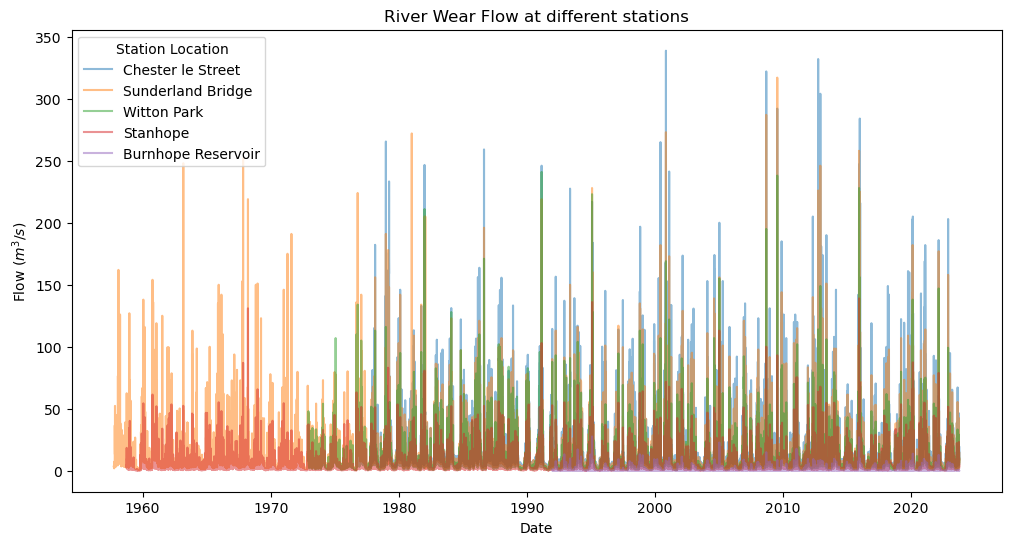

In [11]:
# set up plot
fig, ax = plt.subplots(figsize=(12,6))

# plot each individual station flow data
ax.plot(flow_24009, alpha=0.5, label='Chester le Street')
ax.plot(flow_24001, alpha=0.5, label='Sunderland Bridge')
ax.plot(flow_24008, alpha=0.5, label='Witton Park')
ax.plot(flow_24003, alpha=0.5, label='Stanhope')
ax.plot(flow_24011, alpha=0.5, label='Burnhope Reservoir')

# add labels
ax.set_title('River Wear Flow at different stations')
ax.set_ylabel(r'Flow ($m^3/s$)')
ax.set_xlabel('Date')
plt.legend(title='Station Location')
plt.show()

This plot is very noisy and we gain virtually no insight at all. Also notice the scale and variablility is dominated by major spikes (likely major rainfall), and low level variability is very hard to see. The conter this, we make the scale of y logarithmic:

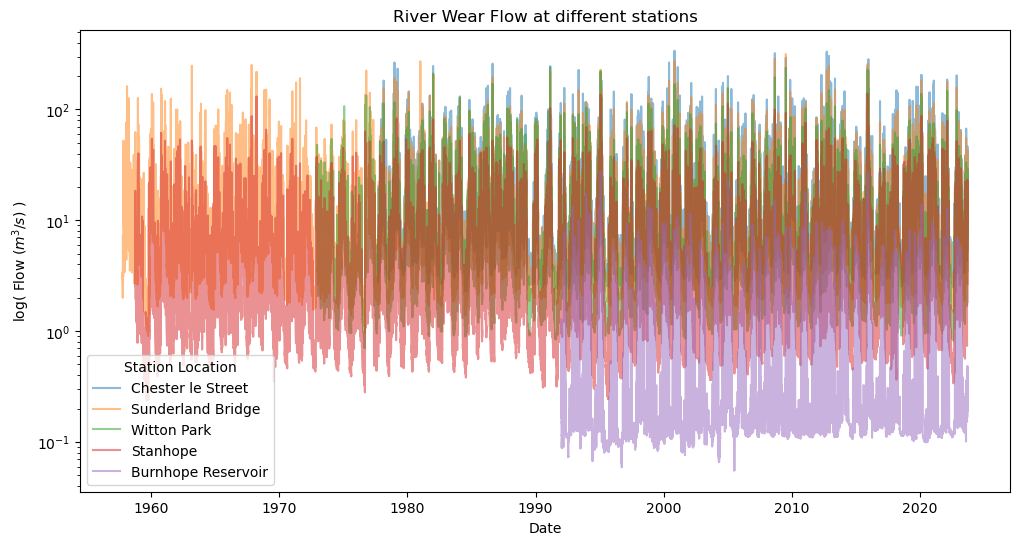

In [12]:
# set up plots
fig, ax = plt.subplots(figsize=(12,6))

# plot flow for each station
ax.plot(flow_24009, alpha=0.5, label='Chester le Street')
ax.plot(flow_24001, alpha=0.5, label='Sunderland Bridge')
ax.plot(flow_24008, alpha=0.5, label='Witton Park')
ax.plot(flow_24003, alpha=0.5, label='Stanhope')
ax.plot(flow_24011, alpha=0.5, label='Burnhope Reservoir')

# set a logarithmic scale
ax.set_yscale('log')

# add labels
ax.set_title('River Wear Flow at different stations')
ax.set_ylabel(r'log( Flow ($m^3/s$) )')
ax.set_xlabel('Date')
plt.legend(title='Station Location')
plt.show()

We can begin to see that flow is consistently larger at more downstream stations, but the plot is still very noisy. We will zoom in on an arbituary date range (we chose first 6 months of 2000) to see more clearly:

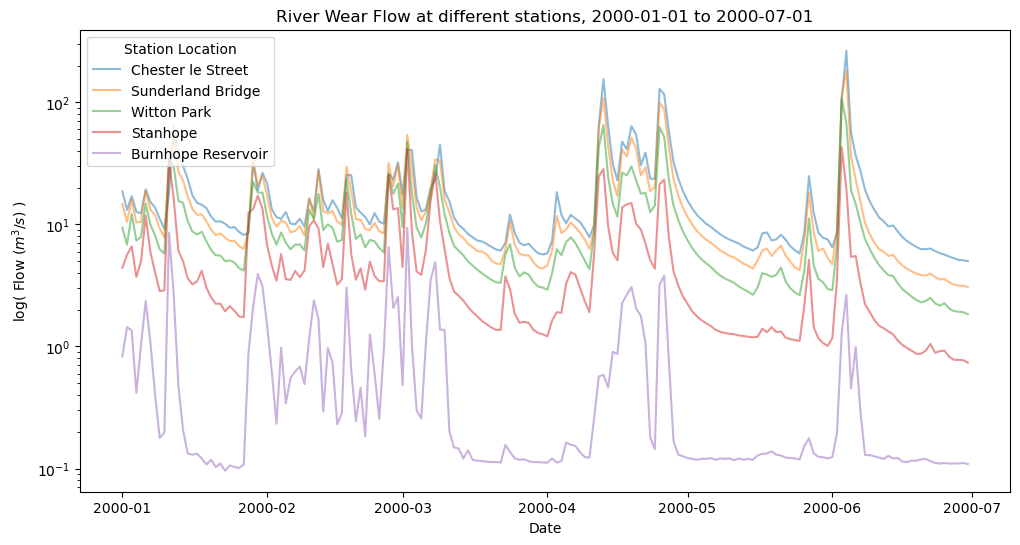

In [13]:
# restrict flow data to date range
START_DATE = '2000-01-01'
END_DATE = '2000-07-01'
time_restriction_1 = (flow_24001.index >= START_DATE) & (flow_24001.index < END_DATE)
time_restriction_3 = (flow_24003.index >= START_DATE) & (flow_24003.index < END_DATE)
time_restriction_8 = (flow_24008.index >= START_DATE) & (flow_24008.index < END_DATE)
time_restriction_9 = (flow_24009.index >= START_DATE) & (flow_24009.index < END_DATE)
time_restriction_11 = (flow_24011.index >= START_DATE) & (flow_24011.index < END_DATE)

# set up plot
fig, ax = plt.subplots(figsize=(12,6))

# plot restricted data on logarithmic scale
ax.plot(flow_24009[time_restriction_9], alpha=0.5, label='Chester le Street')
ax.plot(flow_24001[time_restriction_1], alpha=0.5, label='Sunderland Bridge')
ax.plot(flow_24008[time_restriction_8], alpha=0.5, label='Witton Park')
ax.plot(flow_24003[time_restriction_3], alpha=0.5, label='Stanhope')
ax.plot(flow_24011[time_restriction_11], alpha=0.5, label='Burnhope Reservoir')
ax.set_yscale('log')

# add labels
ax.set_title(f'River Wear Flow at different stations, {START_DATE} to {END_DATE}')
ax.set_ylabel(r'log( Flow ($m^3/s$) )')
ax.set_xlabel('Date')
plt.legend(title='Station Location')
plt.show()

We can now clearly see correlation in where peaks occur for the river flow: flow at all stations moves together, with a small or no lag between stations, with the more upstream stations generally moving first and the downstream following. Let us look in closer detail at the spike in June:

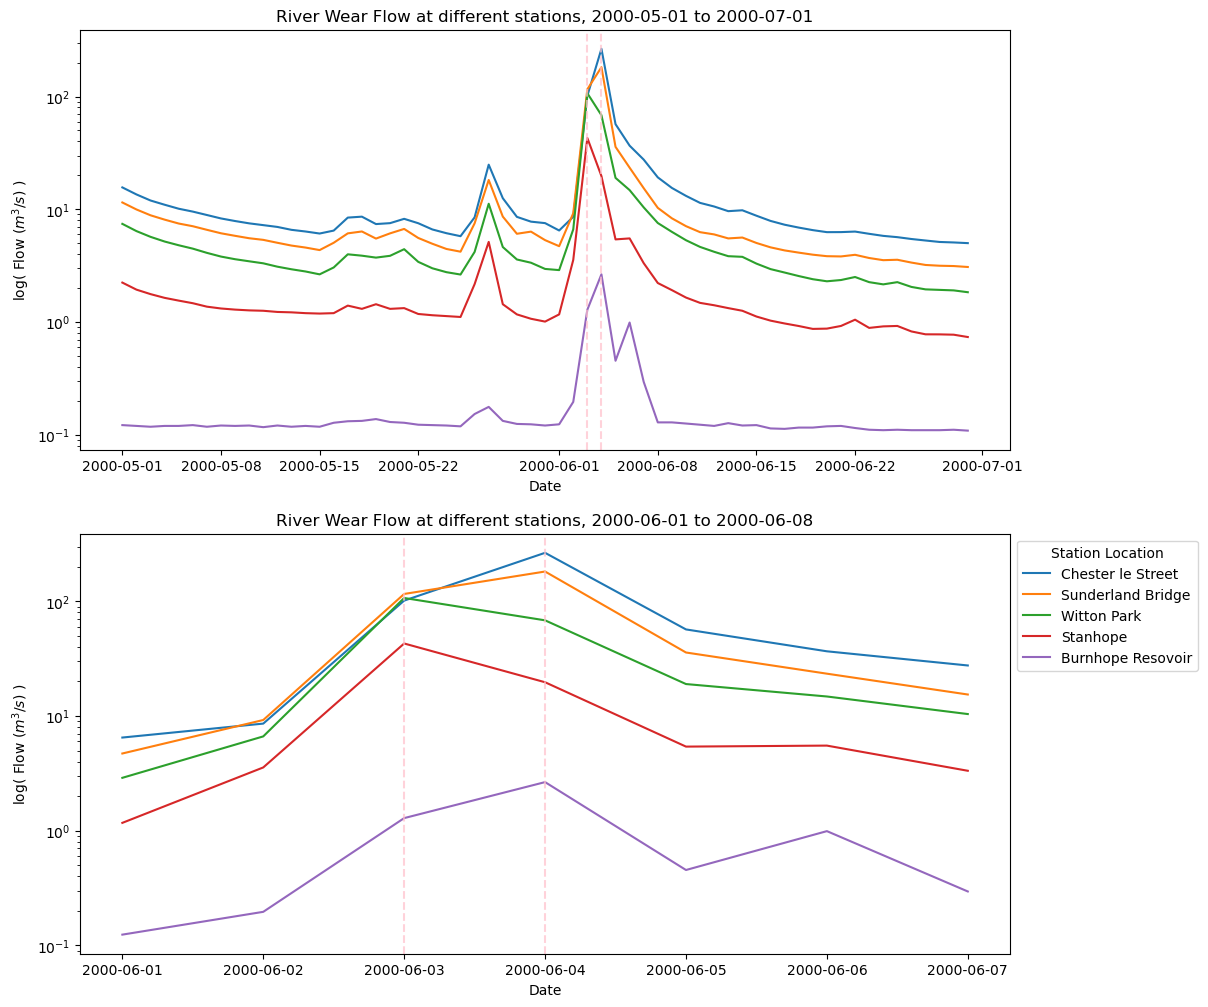

In [14]:
# set up plot
fig, ax = plt.subplots(2, 1, figsize=(12,12))

# first date restriction - wider
START_DATE_1 = '2000-05-01'
END_DATE_1 = '2000-07-01'
time_restriction_1 = (flow_24001.index >= START_DATE_1) & (flow_24001.index < END_DATE_1)
time_restriction_3 = (flow_24003.index >= START_DATE_1) & (flow_24003.index < END_DATE_1)
time_restriction_8 = (flow_24008.index >= START_DATE_1) & (flow_24008.index < END_DATE_1)
time_restriction_9 = (flow_24009.index >= START_DATE_1) & (flow_24009.index < END_DATE_1)
time_restriction_11 = (flow_24011.index >= START_DATE_1) & (flow_24011.index < END_DATE_1)

# plot wider restriction data
ax[0].plot(flow_24009[time_restriction_9], alpha=1, label='Chester le Street')
ax[0].plot(flow_24001[time_restriction_1], alpha=1, label='Sunderland Bridge')
ax[0].plot(flow_24008[time_restriction_8], alpha=1, label='Witton Park')
ax[0].plot(flow_24003[time_restriction_3], alpha=1, label='Stanhope')
ax[0].plot(flow_24011[time_restriction_11], alpha=1, label='Burnhope Resovoir')
# add vertical lines at points of interest
ax[0].axvline(pd.to_datetime('2000-06-04'), color='pink', linestyle='--', alpha=0.7)
ax[0].axvline(pd.to_datetime('2000-06-03'), color='pink', linestyle='--', alpha=0.7)
ax[0].set_yscale('log')
# add labels
ax[0].set_title(f'River Wear Flow at different stations, {START_DATE_1} to {END_DATE_1}')
ax[0].set_ylabel(r'log( Flow ($m^3/s$) )')
ax[0].set_xlabel('Date')

# second date destriction - narrow
START_DATE_2 = '2000-06-01'
END_DATE_2 = '2000-06-08'
time_restriction_1 = (flow_24001.index >= START_DATE_2) & (flow_24001.index < END_DATE_2)
time_restriction_3 = (flow_24003.index >= START_DATE_2) & (flow_24003.index < END_DATE_2)
time_restriction_8 = (flow_24008.index >= START_DATE_2) & (flow_24008.index < END_DATE_2)
time_restriction_9 = (flow_24009.index >= START_DATE_2) & (flow_24009.index < END_DATE_2)
time_restriction_11 = (flow_24011.index >= START_DATE_2) & (flow_24011.index < END_DATE_2)

# plot narrower restriction
ax[1].plot(flow_24009[time_restriction_9], alpha=1, label='Chester le Street')
ax[1].plot(flow_24001[time_restriction_1], alpha=1, label='Sunderland Bridge')
ax[1].plot(flow_24008[time_restriction_8], alpha=1, label='Witton Park')
ax[1].plot(flow_24003[time_restriction_3], alpha=1, label='Stanhope')
ax[1].plot(flow_24011[time_restriction_11], alpha=1, label='Burnhope Resovoir')
# plot vertical lines at points of interest
ax[1].axvline(pd.to_datetime('2000-06-04'), color='pink', linestyle='--', alpha=0.7)
ax[1].axvline(pd.to_datetime('2000-06-03'), color='pink', linestyle='--', alpha=0.7)
ax[1].set_yscale('log')
# add labels
ax[1].set_title(f'River Wear Flow at different stations, {START_DATE_2} to {END_DATE_2}')
ax[1].set_ylabel(r'log( Flow ($m^3/s$) )')
ax[1].set_xlabel('Date')

plt.legend(title='Station Location', bbox_to_anchor=(1,1))
plt.show()

As we expected form before, Stanhope and Witton Park (downstream) peak on the 3rd, while Sunderland Bridge and Chester le Street (upstream) peak on the 4th. This is physical lag, induced by the time it takes for rainwater to flow through the catchment to downstream locations. We must also mention the seemingly anomalous result of the reading from the Burnhope reservoir peaking later. This could be because rain only fell on the lower part of the catchment, but this is unlikely as the flow still rose. What is more likely is it was induced by the reservoir, becoming overfull from the rain and thus releasing later.

We now attempt to quantify an average for this lag, across all events. From the plots we have seen, spikes occur either on the same day or 1 day apart for any. As our data is daily, we cannot see any more detail of timestamps, but we can attempt to take an average across all data (or more so a proprotion of 0 to 1) to determine lag time. We will consider the difference between Chester le Street (most downstream) and Stanhope (second most upstream) to avoid to anomalous behaviour of Burnhope Resrevoir.

To do this we first find the correlation between values on the same day. This gives a measure of how the move together. Then we also calculate the correlation of the upsteam data shifted forwards by a day with the downstream values. This gives a measure of how they move on a 1 day separation. We assume that the lag is between 0 and 1 days, so we do not need to calculate any more correlations. We consder each correlation to be stronger evidence for that lag. We then find the weighted (0, 1) total of the correlations, and then divde by the sum of the correlations to normalise. This gives a value between 0 and 1, which is the average lag in days. We then mulitply this by 24 to get the lag in hours, which form the code below we find is approximately **8.66 hours**.

In [15]:
# find intersection of dates to restrict data
common_dates = flow_24009.index.intersection(flow_24003.index)

# restrict flow data
upstream = flow_24009.loc[common_dates, 'flow']  
downstream = flow_24003.loc[common_dates, 'flow']

# Calculate correlations as described
corr_0 = upstream.corr(downstream) 
corr_1 = upstream.shift(1).corr(downstream) # upstream data shifted forward by a day  

# use the weighted normalization to get the lag in days
lag_days = (0*corr_0 + 1*corr_1) / (corr_0 + corr_1)
lag_hours = 24 * lag_days

# print average lag to 2 d.p.
print(f"Average lag: {lag_hours:.2f} hours")

Average lag: 8.66 hours


As seen in our graphs, river level (flow) can spike a lot, and has a large variability in levels, even higher than seen in our graphs as we are uing a logarithmic scale. Normally, a river level is classified as by one of seven levels: exceptionally low, notably low, below normal, normal, above normal, notably high, and exceptionally high, the values of which change seasonally. 

We will first assume that each level is a percentile, namely:
* Exceptionally low - 0-5th percentile
* Notably Low - 5-15th percentile
* Below Normal - 15-30th percentile
* Normal - 30-70th percentile
* Above Normal - 70-85th percentile
* Notably High - 85-95th percentile
* Exceptionally High - 95-100th percentile
  
As we mentioned, the level changes seaonsally, therefore we will calculate the percentiles separately for each day of the year, +/- 5 days. We do this below for station at Chester le Street (24009). 

In [16]:
# specify what data to use
data = flow_24009.copy()
# add variable for day of year
data['dayofyear'] = data.index.dayofyear

# choose window for calculating percentiles
window = 5

# store percentiles in a dictionary for each day of the year
percentiles = {}

# loop over 1-366 inclusive (all dayd of the year inclusing leap years)
for doy in range(1, 367):
    # set up a mask to only take data of the day +/- 5
    mask = ((data['dayofyear'] >= doy - window) & (data['dayofyear'] <= doy + window))
    # edge cases - where the window wraps over the end of the year
    if doy <= window: 
        mask = np.logical_or(mask, (data['dayofyear'] >= 365 + doy - window))
    if doy >= 365 - window:
        mask = np.logical_or(mask, (data['dayofyear'] <= doy + window - 365))

    # mask the data to calculate percentiles from
    calculation_data = data.loc[mask, 'flow']

    # calculate percentiles and add to dictionary for the day of the year
    percentiles[doy] = {
        'p5': np.percentile(calculation_data, 5),
        'p15': np.percentile(calculation_data, 15),
        'p30': np.percentile(calculation_data, 30),
        'p70': np.percentile(calculation_data, 70),
        'p85': np.percentile(calculation_data, 85),
        'p95': np.percentile(calculation_data, 95)
    }

# add columns to the data for each percentile on wthat day
# lambda function used to call key in dictionary for the day of year
data['p5'] = data['dayofyear'].map(lambda x: percentiles[x]['p5'])
data['p15'] = data['dayofyear'].map(lambda x: percentiles[x]['p15'])
data['p30'] = data['dayofyear'].map(lambda x: percentiles[x]['p30'])
data['p70'] = data['dayofyear'].map(lambda x: percentiles[x]['p70'])
data['p85'] = data['dayofyear'].map(lambda x: percentiles[x]['p85'])
data['p95'] = data['dayofyear'].map(lambda x: percentiles[x]['p95'])

# check data frame
print(data.head())
print(data.info())

# save as percentile flow data for station 24009
percentile_flow_24009 = data

             flow  dayofyear       p5      p15     p30     p70      p85  \
date                                                                      
1977-09-01  4.416        244  2.82710  3.08755  3.4979  5.1370  8.71525   
1977-09-02  4.740        245  2.84880  3.09000  3.4802  5.2478  8.34400   
1977-09-03  4.936        246  2.85210  3.09285  3.4963  5.3120  8.40725   
1977-09-04  4.076        247  2.86850  3.11730  3.5000  5.3454  8.39300   
1977-09-05  3.456        248  2.86475  3.09075  3.4935  5.4640  8.58475   

                p95  
date                 
1977-09-01  16.6955  
1977-09-02  16.4000  
1977-09-03  16.0350  
1977-09-04  16.0300  
1977-09-05  16.3700  
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 16831 entries, 1977-09-01 to 2023-09-30
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   flow       16831 non-null  float64
 1   dayofyear  16831 non-null  int32  
 2   p5         16831 non-null  flo

We have suessfully found the percentiles are each day +/- 5 days. We will now plot the time series for the flow at Chester le Street, including the levels, from 2015-2020 inclusive.

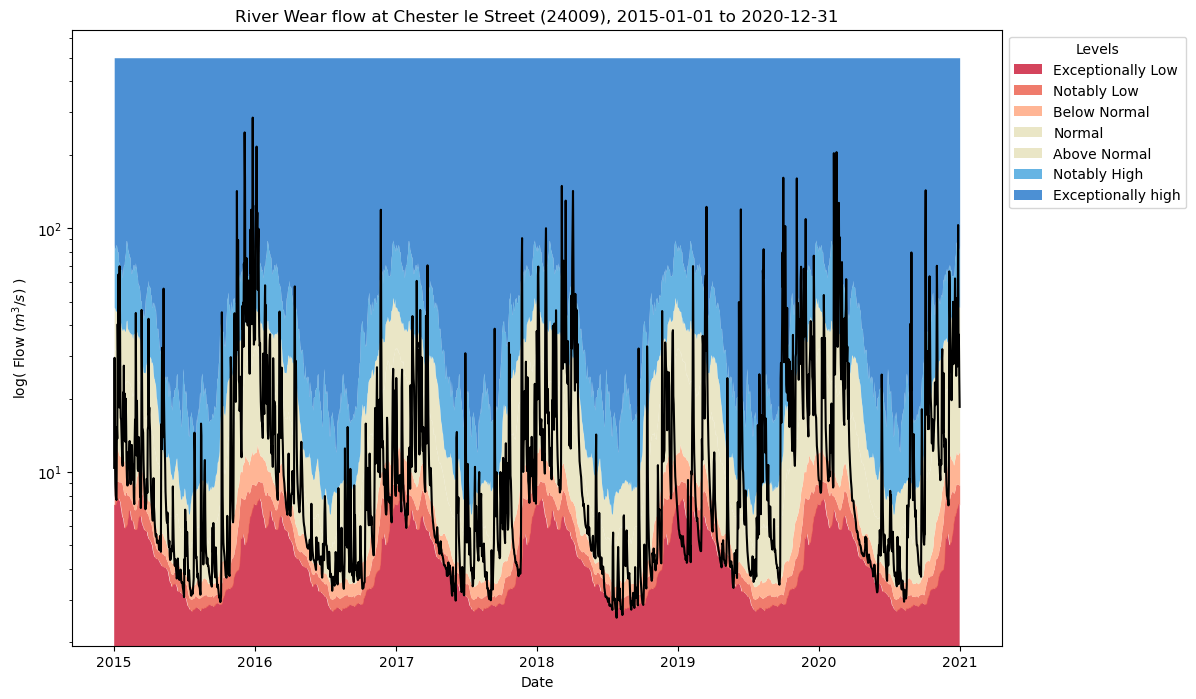

In [17]:
# create mask to restrict timeframe
START_DATE = '2015-01-01'
END_DATE = '2020-12-31'
time_restriction = ((percentile_flow_24009.index >= START_DATE) & (percentile_flow_24009.index <= END_DATE))

# get data for plotting
plot_data = percentile_flow_24009.loc[time_restriction]

# set up plot
fig, ax = plt.subplots(figsize=(12,8)) 

# plot flow timeseries
ax.plot(plot_data.index, plot_data['flow'], color='black')

# add each level on as a solic colour section
ax.fill_between(plot_data.index, 0, plot_data['p5'], color='#cd233f', alpha=0.85, linewidth=0, label='Exceptionally Low')
ax.fill_between(plot_data.index, plot_data['p5'], plot_data['p15'], color='#ed6452', alpha=0.85, linewidth=0, label='Notably Low')
ax.fill_between(plot_data.index, plot_data['p15'], plot_data['p30'], color='#ffa883', alpha=0.85, linewidth=0, label='Below Normal')
ax.fill_between(plot_data.index, plot_data['p30'], plot_data['p70'], color='#e7e2bc', alpha=0.85, linewidth=0, label='Normal')
ax.fill_between(plot_data.index, plot_data['p70'], plot_data['p85'], color='#e7e2bc', alpha=0.85, linewidth=0, label='Above Normal')
ax.fill_between(plot_data.index, plot_data['p85'], plot_data['p95'], color='#4ba7de', alpha=0.85, linewidth=0, label='Notably High')
ax.fill_between(plot_data.index, plot_data['p95'], 500, color='#2c7dcd', alpha=0.85, linewidth=0, label='Exceptionally high')

# logarithmic scale
ax.set_yscale('log')

# add labels
ax.set_title(f'River Wear flow at Chester le Street (24009), {START_DATE} to {END_DATE}')
ax.set_ylabel(r'log( Flow ($m^3/s$) )')
ax.set_xlabel('Date')
plt.legend(bbox_to_anchor=(1,1), title='Levels')
plt.show()

We see that flow levels vary as expected, being lower in the summer months every year. We now repeat the process for the other stations. (Note near indentical code is copied, just using different stations)

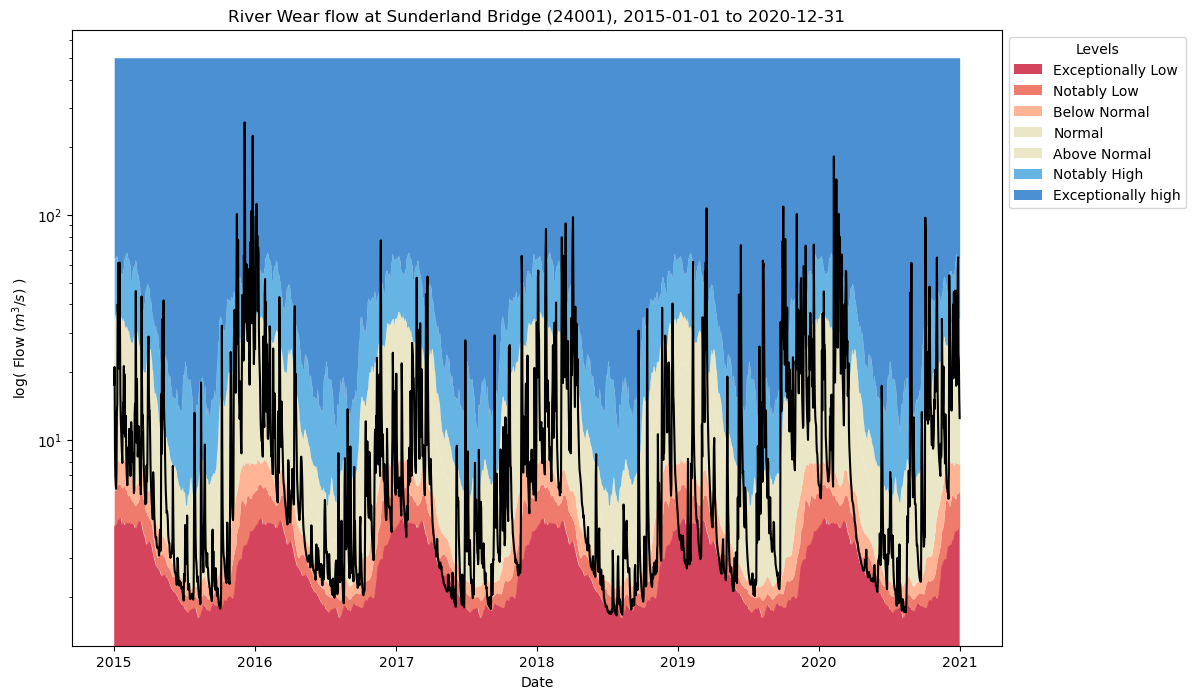

In [18]:
# Sunderland Bridge - 24001

# get percentile data
# specify what data to use
data = flow_24001.copy()
# add variable for day of year
data['dayofyear'] = data.index.dayofyear

# choose window for calculating percentiles
window = 5

# store percentiles in a dictionary for each day of the year
percentiles = {}

# loop over 1-366 inclusive (all dayd of the year inclusing leap years)
for doy in range(1, 367):
    # set up a mask to only take data of the day +/- 5
    mask = ((data['dayofyear'] >= doy - window) & (data['dayofyear'] <= doy + window))
    # edge cases - where the window wraps over the end of the year
    if doy <= window: 
        mask = np.logical_or(mask, (data['dayofyear'] >= 365 + doy - window))
    if doy >= 365 - window:
        mask = np.logical_or(mask, (data['dayofyear'] <= doy + window - 365))

    # mask the data to calculate percentiles from
    calculation_data = data.loc[mask, 'flow']

    # calculate percentiles and add to dictionary for the day of the year
    percentiles[doy] = {
        'p5': np.percentile(calculation_data, 5),
        'p15': np.percentile(calculation_data, 15),
        'p30': np.percentile(calculation_data, 30),
        'p70': np.percentile(calculation_data, 70),
        'p85': np.percentile(calculation_data, 85),
        'p95': np.percentile(calculation_data, 95)
    }

# add columns to the data for each percentile on wthat day
# lambda function used to call key in dictionary for the day of year
data['p5'] = data['dayofyear'].map(lambda x: percentiles[x]['p5'])
data['p15'] = data['dayofyear'].map(lambda x: percentiles[x]['p15'])
data['p30'] = data['dayofyear'].map(lambda x: percentiles[x]['p30'])
data['p70'] = data['dayofyear'].map(lambda x: percentiles[x]['p70'])
data['p85'] = data['dayofyear'].map(lambda x: percentiles[x]['p85'])
data['p95'] = data['dayofyear'].map(lambda x: percentiles[x]['p95'])

# save as percentile flow data for station 24001
percentile_flow_24001 = data

# plot 2015-2020
# create mask to restrict timeframe
START_DATE = '2015-01-01'
END_DATE = '2020-12-31'
time_restriction = ((percentile_flow_24001.index >= START_DATE) & (percentile_flow_24001.index <= END_DATE))

# get data for plotting
plot_data = percentile_flow_24001.loc[time_restriction]

# set up plot
fig, ax = plt.subplots(figsize=(12,8)) 

# plot flow timeseries
ax.plot(plot_data.index, plot_data['flow'], color='black')

# add each level on as a solic colour section
ax.fill_between(plot_data.index, 0, plot_data['p5'], color='#cd233f', alpha=0.85, linewidth=0, label='Exceptionally Low')
ax.fill_between(plot_data.index, plot_data['p5'], plot_data['p15'], color='#ed6452', alpha=0.85, linewidth=0, label='Notably Low')
ax.fill_between(plot_data.index, plot_data['p15'], plot_data['p30'], color='#ffa883', alpha=0.85, linewidth=0, label='Below Normal')
ax.fill_between(plot_data.index, plot_data['p30'], plot_data['p70'], color='#e7e2bc', alpha=0.85, linewidth=0, label='Normal')
ax.fill_between(plot_data.index, plot_data['p70'], plot_data['p85'], color='#e7e2bc', alpha=0.85, linewidth=0, label='Above Normal')
ax.fill_between(plot_data.index, plot_data['p85'], plot_data['p95'], color='#4ba7de', alpha=0.85, linewidth=0, label='Notably High')
ax.fill_between(plot_data.index, plot_data['p95'], 500, color='#2c7dcd', alpha=0.85, linewidth=0, label='Exceptionally high')

# logarithmic scale
ax.set_yscale('log')

# add labels
ax.set_title(f'River Wear flow at Sunderland Bridge (24001), {START_DATE} to {END_DATE}')
ax.set_ylabel(r'log( Flow ($m^3/s$) )')
ax.set_xlabel('Date')
plt.legend(bbox_to_anchor=(1,1), title='Levels')
plt.show()

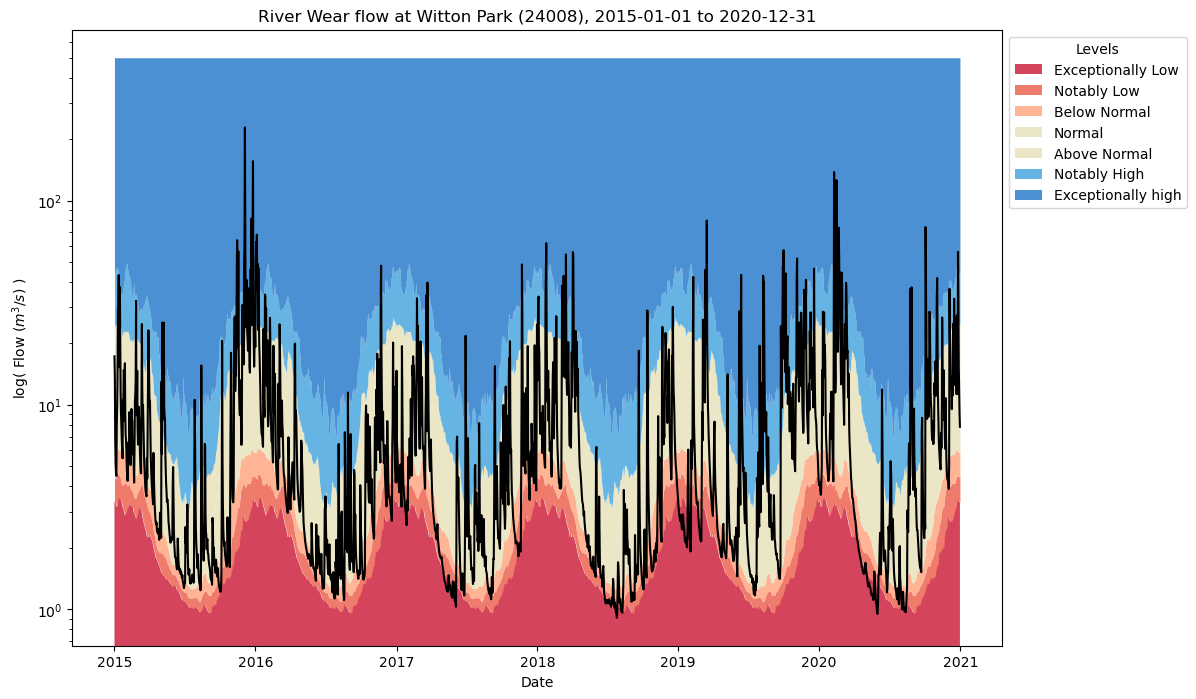

In [19]:
# Witton Park - 24008

# get percentile data
# specify what data to use
data = flow_24008.copy()
# add variable for day of year
data['dayofyear'] = data.index.dayofyear

# choose window for calculating percentiles
window = 5

# store percentiles in a dictionary for each day of the year
percentiles = {}

# loop over 1-366 inclusive (all dayd of the year inclusing leap years)
for doy in range(1, 367):
    # set up a mask to only take data of the day +/- 5
    mask = ((data['dayofyear'] >= doy - window) & (data['dayofyear'] <= doy + window))
    # edge cases - where the window wraps over the end of the year
    if doy <= window: 
        mask = np.logical_or(mask, (data['dayofyear'] >= 365 + doy - window))
    if doy >= 365 - window:
        mask = np.logical_or(mask, (data['dayofyear'] <= doy + window - 365))

    # mask the data to calculate percentiles from
    calculation_data = data.loc[mask, 'flow']

    # calculate percentiles and add to dictionary for the day of the year
    percentiles[doy] = {
        'p5': np.percentile(calculation_data, 5),
        'p15': np.percentile(calculation_data, 15),
        'p30': np.percentile(calculation_data, 30),
        'p70': np.percentile(calculation_data, 70),
        'p85': np.percentile(calculation_data, 85),
        'p95': np.percentile(calculation_data, 95)
    }

# add columns to the data for each percentile on wthat day
# lambda function used to call key in dictionary for the day of year
data['p5'] = data['dayofyear'].map(lambda x: percentiles[x]['p5'])
data['p15'] = data['dayofyear'].map(lambda x: percentiles[x]['p15'])
data['p30'] = data['dayofyear'].map(lambda x: percentiles[x]['p30'])
data['p70'] = data['dayofyear'].map(lambda x: percentiles[x]['p70'])
data['p85'] = data['dayofyear'].map(lambda x: percentiles[x]['p85'])
data['p95'] = data['dayofyear'].map(lambda x: percentiles[x]['p95'])

# save as percentile flow data for station 24008
percentile_flow_24008 = data

# plot 2015-2020
# create mask to restrict timeframe
START_DATE = '2015-01-01'
END_DATE = '2020-12-31'
time_restriction = ((percentile_flow_24008.index >= START_DATE) & (percentile_flow_24008.index <= END_DATE))

# get data for plotting
plot_data = percentile_flow_24008.loc[time_restriction]

# set up plot
fig, ax = plt.subplots(figsize=(12,8)) 

# plot flow timeseries
ax.plot(plot_data.index, plot_data['flow'], color='black')

# add each level on as a solic colour section
ax.fill_between(plot_data.index, 0, plot_data['p5'], color='#cd233f', alpha=0.85, linewidth=0, label='Exceptionally Low')
ax.fill_between(plot_data.index, plot_data['p5'], plot_data['p15'], color='#ed6452', alpha=0.85, linewidth=0, label='Notably Low')
ax.fill_between(plot_data.index, plot_data['p15'], plot_data['p30'], color='#ffa883', alpha=0.85, linewidth=0, label='Below Normal')
ax.fill_between(plot_data.index, plot_data['p30'], plot_data['p70'], color='#e7e2bc', alpha=0.85, linewidth=0, label='Normal')
ax.fill_between(plot_data.index, plot_data['p70'], plot_data['p85'], color='#e7e2bc', alpha=0.85, linewidth=0, label='Above Normal')
ax.fill_between(plot_data.index, plot_data['p85'], plot_data['p95'], color='#4ba7de', alpha=0.85, linewidth=0, label='Notably High')
ax.fill_between(plot_data.index, plot_data['p95'], 500, color='#2c7dcd', alpha=0.85, linewidth=0, label='Exceptionally high')

# logarithmic scale
ax.set_yscale('log')

# add labels
ax.set_title(f'River Wear flow at Witton Park (24008), {START_DATE} to {END_DATE}')
ax.set_ylabel(r'log( Flow ($m^3/s$) )')
ax.set_xlabel('Date')
plt.legend(bbox_to_anchor=(1,1), title='Levels')
plt.show()

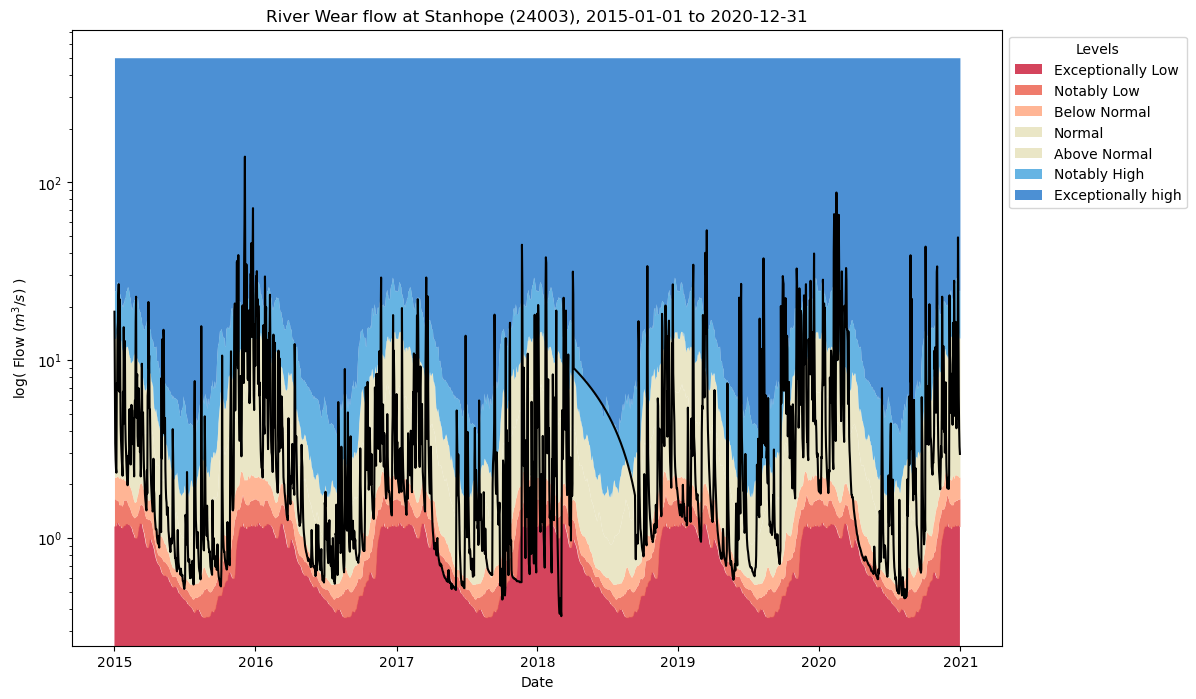

In [20]:
# Stanhope - 24003

# get percentile data
# specify what data to use
data = flow_24003.copy()
# add variable for day of year
data['dayofyear'] = data.index.dayofyear

# choose window for calculating percentiles
window = 5

# store percentiles in a dictionary for each day of the year
percentiles = {}

# loop over 1-366 inclusive (all dayd of the year inclusing leap years)
for doy in range(1, 367):
    # set up a mask to only take data of the day +/- 5
    mask = ((data['dayofyear'] >= doy - window) & (data['dayofyear'] <= doy + window))
    # edge cases - where the window wraps over the end of the year
    if doy <= window: 
        mask = np.logical_or(mask, (data['dayofyear'] >= 365 + doy - window))
    if doy >= 365 - window:
        mask = np.logical_or(mask, (data['dayofyear'] <= doy + window - 365))

    # mask the data to calculate percentiles from
    calculation_data = data.loc[mask, 'flow']

    # calculate percentiles and add to dictionary for the day of the year
    percentiles[doy] = {
        'p5': np.percentile(calculation_data, 5),
        'p15': np.percentile(calculation_data, 15),
        'p30': np.percentile(calculation_data, 30),
        'p70': np.percentile(calculation_data, 70),
        'p85': np.percentile(calculation_data, 85),
        'p95': np.percentile(calculation_data, 95)
    }

# add columns to the data for each percentile on wthat day
# lambda function used to call key in dictionary for the day of year
data['p5'] = data['dayofyear'].map(lambda x: percentiles[x]['p5'])
data['p15'] = data['dayofyear'].map(lambda x: percentiles[x]['p15'])
data['p30'] = data['dayofyear'].map(lambda x: percentiles[x]['p30'])
data['p70'] = data['dayofyear'].map(lambda x: percentiles[x]['p70'])
data['p85'] = data['dayofyear'].map(lambda x: percentiles[x]['p85'])
data['p95'] = data['dayofyear'].map(lambda x: percentiles[x]['p95'])

# save as percentile flow data for station 24003
percentile_flow_24003 = data

# plot 2015-2020
# create mask to restrict timeframe
START_DATE = '2015-01-01'
END_DATE = '2020-12-31'
time_restriction = ((percentile_flow_24003.index >= START_DATE) & (percentile_flow_24003.index <= END_DATE))

# get data for plotting
plot_data = percentile_flow_24003.loc[time_restriction]

# set up plot
fig, ax = plt.subplots(figsize=(12,8)) 

# plot flow timeseries
ax.plot(plot_data.index, plot_data['flow'], color='black')

# add each level on as a solic colour section
ax.fill_between(plot_data.index, 0, plot_data['p5'], color='#cd233f', alpha=0.85, linewidth=0, label='Exceptionally Low')
ax.fill_between(plot_data.index, plot_data['p5'], plot_data['p15'], color='#ed6452', alpha=0.85, linewidth=0, label='Notably Low')
ax.fill_between(plot_data.index, plot_data['p15'], plot_data['p30'], color='#ffa883', alpha=0.85, linewidth=0, label='Below Normal')
ax.fill_between(plot_data.index, plot_data['p30'], plot_data['p70'], color='#e7e2bc', alpha=0.85, linewidth=0, label='Normal')
ax.fill_between(plot_data.index, plot_data['p70'], plot_data['p85'], color='#e7e2bc', alpha=0.85, linewidth=0, label='Above Normal')
ax.fill_between(plot_data.index, plot_data['p85'], plot_data['p95'], color='#4ba7de', alpha=0.85, linewidth=0, label='Notably High')
ax.fill_between(plot_data.index, plot_data['p95'], 500, color='#2c7dcd', alpha=0.85, linewidth=0, label='Exceptionally high')

# logarithmic scale
ax.set_yscale('log')

# add labels
ax.set_title(f'River Wear flow at Stanhope (24003), {START_DATE} to {END_DATE}')
ax.set_ylabel(r'log( Flow ($m^3/s$) )')
ax.set_xlabel('Date')
plt.legend(bbox_to_anchor=(1,1), title='Levels')
plt.show()

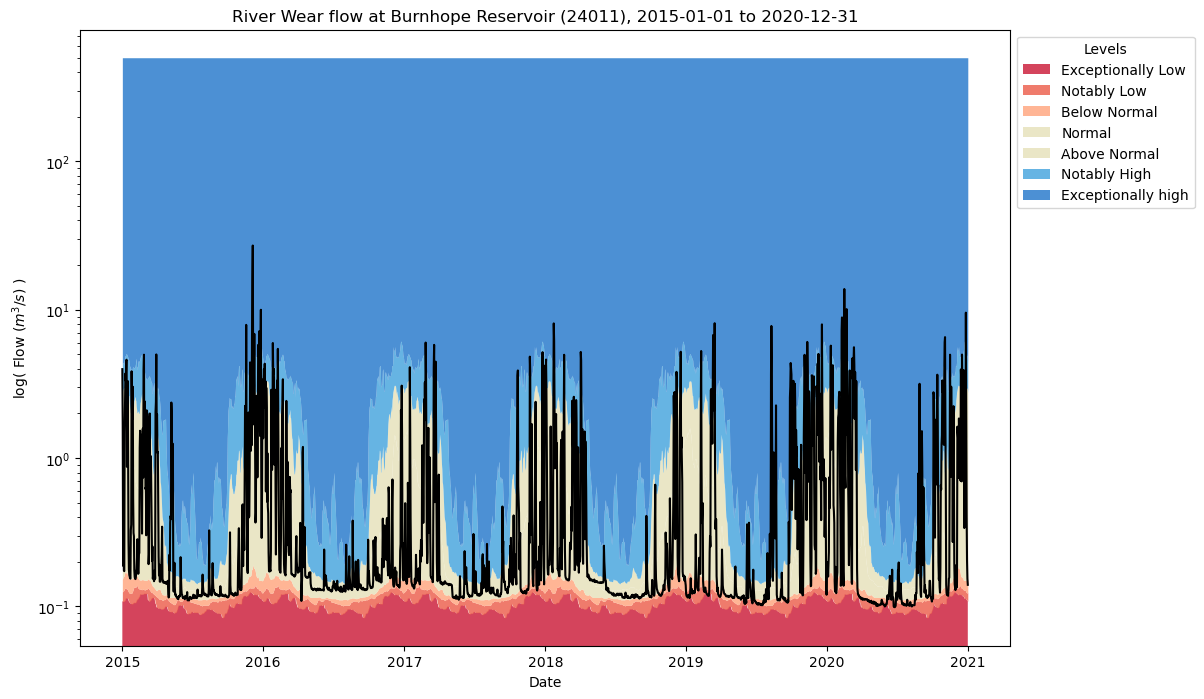

In [21]:
# Burnhope Resrevoir - 24011

# get percentile data
# specify what data to use
data = flow_24011.copy()
# add variable for day of year
data['dayofyear'] = data.index.dayofyear

# choose window for calculating percentiles
window = 5

# store percentiles in a dictionary for each day of the year
percentiles = {}

# loop over 1-366 inclusive (all dayd of the year inclusing leap years)
for doy in range(1, 367):
    # set up a mask to only take data of the day +/- 5
    mask = ((data['dayofyear'] >= doy - window) & (data['dayofyear'] <= doy + window))
    # edge cases - where the window wraps over the end of the year
    if doy <= window: 
        mask = np.logical_or(mask, (data['dayofyear'] >= 365 + doy - window))
    if doy >= 365 - window:
        mask = np.logical_or(mask, (data['dayofyear'] <= doy + window - 365))

    # mask the data to calculate percentiles from
    calculation_data = data.loc[mask, 'flow']

    # calculate percentiles and add to dictionary for the day of the year
    percentiles[doy] = {
        'p5': np.percentile(calculation_data, 5),
        'p15': np.percentile(calculation_data, 15),
        'p30': np.percentile(calculation_data, 30),
        'p70': np.percentile(calculation_data, 70),
        'p85': np.percentile(calculation_data, 85),
        'p95': np.percentile(calculation_data, 95)
    }

# add columns to the data for each percentile on wthat day
# lambda function used to call key in dictionary for the day of year
data['p5'] = data['dayofyear'].map(lambda x: percentiles[x]['p5'])
data['p15'] = data['dayofyear'].map(lambda x: percentiles[x]['p15'])
data['p30'] = data['dayofyear'].map(lambda x: percentiles[x]['p30'])
data['p70'] = data['dayofyear'].map(lambda x: percentiles[x]['p70'])
data['p85'] = data['dayofyear'].map(lambda x: percentiles[x]['p85'])
data['p95'] = data['dayofyear'].map(lambda x: percentiles[x]['p95'])

# save as percentile flow data for station 24011
percentile_flow_24011 = data

# plot 2015-2020
# create mask to restrict timeframe
START_DATE = '2015-01-01'
END_DATE = '2020-12-31'
time_restriction = ((percentile_flow_24011.index >= START_DATE) & (percentile_flow_24011.index <= END_DATE))

# get data for plotting
plot_data = percentile_flow_24011.loc[time_restriction]

# set up plot
fig, ax = plt.subplots(figsize=(12,8)) 

# plot flow timeseries
ax.plot(plot_data.index, plot_data['flow'], color='black')

# add each level on as a solic colour section
ax.fill_between(plot_data.index, 0, plot_data['p5'], color='#cd233f', alpha=0.85, linewidth=0, label='Exceptionally Low')
ax.fill_between(plot_data.index, plot_data['p5'], plot_data['p15'], color='#ed6452', alpha=0.85, linewidth=0, label='Notably Low')
ax.fill_between(plot_data.index, plot_data['p15'], plot_data['p30'], color='#ffa883', alpha=0.85, linewidth=0, label='Below Normal')
ax.fill_between(plot_data.index, plot_data['p30'], plot_data['p70'], color='#e7e2bc', alpha=0.85, linewidth=0, label='Normal')
ax.fill_between(plot_data.index, plot_data['p70'], plot_data['p85'], color='#e7e2bc', alpha=0.85, linewidth=0, label='Above Normal')
ax.fill_between(plot_data.index, plot_data['p85'], plot_data['p95'], color='#4ba7de', alpha=0.85, linewidth=0, label='Notably High')
ax.fill_between(plot_data.index, plot_data['p95'], 500, color='#2c7dcd', alpha=0.85, linewidth=0, label='Exceptionally high')

# logarithmic scale
ax.set_yscale('log')

# add labels
ax.set_title(f'River Wear flow at Burnhope Reservoir (24011), {START_DATE} to {END_DATE}')
ax.set_ylabel(r'log( Flow ($m^3/s$) )')
ax.set_xlabel('Date')
plt.legend(bbox_to_anchor=(1,1), title='Levels')
plt.show()

These graphs actually offer some more insight than what we found in intial exploration. Notice some oddities around the interpolation of values on the Stanhope graph, having no all data interpolated in summer of 2018 - this is seen due to the sloping line rather than normal varibaility. Also notice the squarer pattern of the Burnhope Resovoir, likely from the resovoir being overfull more in the winter, meaning flow is artifically increased then.

The levels we found and plotted can also be very useful for monitoring flood and drought risk. For floods, I think alerts should be issues for anything that becomes exceptionally high (>=95 percentile). This is rare enough to determine an anomalous state, while also being common enough to be useful operationally. For droughts, I would issue alerts for anything exceptionally low (<= 5th percentile), using the same justification as for floods.

Using this system, from 2015 to 2020 (inclusive) we see that there would have been the following amount of floods and drought alerts issued at each station (found using code below):
* Chester le Street: 99 floods, 118 droughts
* Sunderland Bridge: 109 floods, 148 droughts
* Witton Park: 99 floods, 147 droughts
* Stanhope: 159 floods, 110 droughts
* Burnhope Reservoir: 100 floods, 9 droughts

In [22]:
# Chester le Street - 24009

# restrict timeframe
START_DATE = '2015-01-01'
END_DATE = '2020-12-31'
time_restriction = ((percentile_flow_24009.index >= START_DATE) & (percentile_flow_24009.index <= END_DATE))
data = percentile_flow_24009.loc[time_restriction]

# count how many entries have value below 5th percentile (drought)
droughts = np.sum(data['flow'] <= data['p5'])
# count how many entries have value above 95th percentile (flood)
floods = np.sum(data['flow'] >= data['p95'])

print(f"# Droughts 2015-2020: {droughts}")
print(f"# Floods 2015-2020: {floods}")

# Droughts 2015-2020: 118
# Floods 2015-2020: 99


In [23]:
# Sunderland Bridge - 24001

# restrict timeframe
START_DATE = '2015-01-01'
END_DATE = '2020-12-31'
time_restriction = ((percentile_flow_24001.index >= START_DATE) & (percentile_flow_24001.index <= END_DATE))
data = percentile_flow_24001.loc[time_restriction]

# count how many entries have value below 5th percentile (drought)
droughts = np.sum(data['flow'] <= data['p5'])
# count how many entries have value above 95th percentile (flood)
floods = np.sum(data['flow'] >= data['p95'])

print(f"# Droughts 2015-2020: {droughts}")
print(f"# Floods 2015-2020: {floods}")

# Droughts 2015-2020: 148
# Floods 2015-2020: 109


In [24]:
# Witton Park - 24008

# restrict timeframe
START_DATE = '2015-01-01'
END_DATE = '2020-12-31'
time_restriction = ((percentile_flow_24008.index >= START_DATE) & (percentile_flow_24008.index <= END_DATE))
data = percentile_flow_24008.loc[time_restriction]

# count how many entries have value below 5th percentile (drought)
droughts = np.sum(data['flow'] <= data['p5'])
# count how many entries have value above 95th percentile (flood)
floods = np.sum(data['flow'] >= data['p95'])

print(f"# Droughts 2015-2020: {droughts}")
print(f"# Floods 2015-2020: {floods}")

# Droughts 2015-2020: 147
# Floods 2015-2020: 99


In [25]:
# Stanhope - 24003
# restrict timeframe
START_DATE = '2015-01-01'
END_DATE = '2020-12-31'
time_restriction = ((percentile_flow_24003.index >= START_DATE) & (percentile_flow_24003.index <= END_DATE))
data = percentile_flow_24003.loc[time_restriction]

# count how many entries have value below 5th percentile (drought)
droughts = np.sum(data['flow'] <= data['p5'])
# count how many entries have value above 95th percentile (flood)
floods = np.sum(data['flow'] >= data['p95'])

print(f"# Droughts 2015-2020: {droughts}")
print(f"# Floods 2015-2020: {floods}")

# Droughts 2015-2020: 110
# Floods 2015-2020: 159


In [26]:
# Burnhope Resovoir - 24011

# restrict timeframe
START_DATE = '2015-01-01'
END_DATE = '2020-12-31'
time_restriction = ((percentile_flow_24011.index >= START_DATE) & (percentile_flow_24011.index <= END_DATE))
data = percentile_flow_24011.loc[time_restriction]

# count how many entries have value below 5th percentile (drought)
droughts = np.sum(data['flow'] <= data['p5'])
# count how many entries have value above 95th percentile (flood)
floods = np.sum(data['flow'] >= data['p95'])

print(f"# Droughts 2015-2020: {droughts}")
print(f"# Floods 2015-2020: {floods}")

# Droughts 2015-2020: 9
# Floods 2015-2020: 100


## Section 2 [Core, 12 marks]: The River Wear and Rainfall Data

- Use [https://nrfa.ceh.ac.uk/data/search](https://nrfa.ceh.ac.uk/data/search) to find the catchment area for each of the gauges used above.
- Is there a correlation between catchment size and mean flow? What about the 5th centile flow or the 95th centile flow? Is there a correlation with the seasonal variablity? What are the uncertainties?
- Find and download the catchment daily rainfall for the gauges and add them to the `RiverWearData` folder.
- Explore the relationship between the rainfall and river flow for each catchment.

From the National River Flow Archive Website, we find the catchment area for each guage are as follows:
* Chester le Street (24009) - $1008.3 \text{km}^2$
* Sunderland Bridge (24001) - $657.8 \text{km}^2$
* Witton Park (24008) - $455 \text{km}^2$
* Stanhope (24003) - $171.9 \text{km}^2$
* Burnhope Reservoir (24011) - $20.5 \text{km}^2$

Let us first compare these to the mean flow at each station.

In [27]:
# set up array of catchment areas
catchment_areas = np.array([1008.3, 657.8, 455, 171.9, 20.5])

# calculate mean flow for all stations
mean_24009 = flow_24009['flow'].mean()
mean_24001 = flow_24001['flow'].mean()
mean_24008 = flow_24008['flow'].mean()
mean_24003 = flow_24003['flow'].mean()
mean_24011 = flow_24011['flow'].mean()
# store mean flows in array
mean_flows = np.array([mean_24009, mean_24001, mean_24008, mean_24003, mean_24011])

# cacluate correlation coefficient using pearsonr of scipy.stats to be able to extract confidence interval 
result = stats.pearsonr(mean_flows, catchment_areas)

r = result.statistic
ci = result.confidence_interval(confidence_level=0.95)

# print results
print(f"Mean flow 24009: {mean_24009:.2f}")
print(f"Mean flow 24001: {mean_24001:.2f}")
print(f"Mean flow 24008: {mean_24008:.2f}")
print(f"Mean flow 24003: {mean_24003:.2f}")
print(f"Mean flow 24011: {mean_24011:.2f}")
print(f"Correlation between mean flow and catchment size (r): {r:.3f}")
print(f"95% sure r lies in {ci}")

Mean flow 24009: 15.00
Mean flow 24001: 11.40
Mean flow 24008: 7.96
Mean flow 24003: 3.95
Mean flow 24011: 0.57
Correlation between mean flow and catchment size (r): 0.993
95% sure r lies in ConfidenceInterval(low=np.float64(0.8868699745545122), high=np.float64(0.9995309679582662))


As we can see there is a very strong linear correlation between mean flow and catchment size ($r \approx 0.993$). We can be 95% sure that this values lies in the interval $[0.887, 0.999]$, showing that these are positively correlated with low uncertainty.

We reapeat this analysis for 5th and 95th percentile flows.

In [28]:
# calculate 5th percentile flow for all stations
fifth_24009 = np.percentile(flow_24009['flow'], 5)
fifth_24001 = np.percentile(flow_24001['flow'], 5)
fifth_24008 = np.percentile(flow_24008['flow'], 5)
fifth_24003 = np.percentile(flow_24003['flow'], 5)
fifth_24011 = np.percentile(flow_24011['flow'], 5)
# store percentile flows in array
fifth_flows = np.array([fifth_24009, fifth_24001, fifth_24008, fifth_24003, fifth_24011])

# cacluate correlation coefficient using pearsonr of scipy.stats to be able to extract confidence interval 
result = stats.pearsonr(fifth_flows, catchment_areas)

r = result.statistic
ci = result.confidence_interval(confidence_level=0.95)

# print results
print(f"5th Percentile flow 24009: {fifth_24009:.2f}")
print(f"5th Percentile flow 24001: {fifth_24001:.2f}")
print(f"5th Percentile flow 24008: {fifth_24008:.2f}")
print(f"5th Percentile flow 24003: {fifth_24003:.2f}")
print(f"5th Percentile flow 24011: {fifth_24011:.2f}")
print(f"Correlation between 5th Percentile flow and catchment size (r): {r:.3f}")
print(f"95% sure r lies in {ci}")

5th Percentile flow 24009: 3.15
5th Percentile flow 24001: 2.01
5th Percentile flow 24008: 1.20
5th Percentile flow 24003: 0.51
5th Percentile flow 24011: 0.10
Correlation between 5th Percentile flow and catchment size (r): 0.997
95% sure r lies in ConfidenceInterval(low=np.float64(0.9481282153915104), high=np.float64(0.9997916771652838))


In [29]:
# calculate 95th percentile flow for all stations
nine5_24009 = np.percentile(flow_24009['flow'], 95)
nine5_24001 = np.percentile(flow_24001['flow'], 95)
nine5_24008 = np.percentile(flow_24008['flow'], 95)
nine5_24003 = np.percentile(flow_24003['flow'], 95)
nine5_24011 = np.percentile(flow_24011['flow'], 95)
# store percentile flows in array
nine5_flows = np.array([nine5_24009, nine5_24001, nine5_24008, nine5_24003, nine5_24011])

# cacluate correlation coefficient using pearsonr of scipy.stats to be able to extract confidence interval 
result = stats.pearsonr(nine5_flows, catchment_areas)

r = result.statistic
ci = result.confidence_interval(confidence_level=0.95)

# print results
print(f"5th Percentile flow 24009: {nine5_24009:.2f}")
print(f"5th Percentile flow 24001: {nine5_24001:.2f}")
print(f"5th Percentile flow 24008: {nine5_24008:.2f}")
print(f"5th Percentile flow 24003: {nine5_24003:.2f}")
print(f"5th Percentile flow 24011: {nine5_24011:.2f}")
print(f"Correlation between 5th Percentile flow and catchment size (r): {r:.3f}")
print(f"95% sure r lies in {ci}")

5th Percentile flow 24009: 49.60
5th Percentile flow 24001: 39.90
5th Percentile flow 24008: 27.70
5th Percentile flow 24003: 15.60
5th Percentile flow 24011: 2.99
Correlation between 5th Percentile flow and catchment size (r): 0.986
95% sure r lies in ConfidenceInterval(low=np.float64(0.7917576256491318), high=np.float64(0.9990910062915771))


As with mean, the 5th and 95th percentile values exhibit very strong linear correlation with catchment size, with respective $r$ values approximately $0.997$ and $0.986$. Once again we can be very certain of strong positive correlation, with 95% confidence intervals of $[0.948, 0.999]$ and $[0.791, 0.999]$ for 5th and 95th percentiles respectively. 

Finally, we will investigate whether or not this correlation holds seasonally.

In [30]:
# winter; set months 
months = np.array([12, 1, 2])

# take the average for each station over the defined season (winter)
winter_24009 = flow_24009[flow_24009.index.month.isin(months)]['flow'].dropna().mean()
winter_24001 = flow_24001[flow_24001.index.month.isin(months)]['flow'].dropna().mean()
winter_24008 = flow_24008[flow_24008.index.month.isin(months)]['flow'].dropna().mean()
winter_24003 = flow_24003[flow_24003.index.month.isin(months)]['flow'].dropna().mean()
winter_24011 = flow_24011[flow_24011.index.month.isin(months)]['flow'].dropna().mean()

# store seasonal flow mean in array
winter_flows = np.array([winter_24009, winter_24001, winter_24008, winter_24003, winter_24011])

# cacluate correlation coefficient using pearsonr of scipy.stats to be able to extract confidence interval 
result = stats.pearsonr(winter_flows, catchment_areas)

r = result.statistic
ci = result.confidence_interval(confidence_level=0.95)

# print results
print(f"Correlation between Winter flow mean and catchment size (r): {r:.3f}")
print(f"95% sure r lies in {ci}")

Correlation between Winter flow mean and catchment size (r): 0.993
95% sure r lies in ConfidenceInterval(low=np.float64(0.8912807252194049), high=np.float64(0.9995503015913944))


In [31]:
# spring; set months 
months = np.array([3, 4, 5])

# take the average for each station over the defined season (winter)
spring_24009 = flow_24009[flow_24009.index.month.isin(months)]['flow'].dropna().mean()
spring_24001 = flow_24001[flow_24001.index.month.isin(months)]['flow'].dropna().mean()
spring_24008 = flow_24008[flow_24008.index.month.isin(months)]['flow'].dropna().mean()
spring_24003 = flow_24003[flow_24003.index.month.isin(months)]['flow'].dropna().mean()
spring_24011 = flow_24011[flow_24011.index.month.isin(months)]['flow'].dropna().mean()

# store seasonal flow mean in array
spring_flows = np.array([spring_24009, spring_24001, spring_24008, spring_24003, spring_24011])

# cacluate correlation coefficient using pearsonr of scipy.stats to be able to extract confidence interval 
result = stats.pearsonr(spring_flows, catchment_areas)

r = result.statistic
ci = result.confidence_interval(confidence_level=0.95)

# print results
print(f"Correlation between Spring flow mean and catchment size (r): {r:.3f}")
print(f"95% sure r lies in {ci}")

Correlation between Spring flow mean and catchment size (r): 0.993
95% sure r lies in ConfidenceInterval(low=np.float64(0.889707841128764), high=np.float64(0.9995434174830433))


In [32]:
# summer; set months 
months = np.array([6, 7, 8])

# take the average for each station over the defined season (winter)
summer_24009 = flow_24009[flow_24009.index.month.isin(months)]['flow'].dropna().mean()
summer_24001 = flow_24001[flow_24001.index.month.isin(months)]['flow'].dropna().mean()
summer_24008 = flow_24008[flow_24008.index.month.isin(months)]['flow'].dropna().mean()
summer_24003 = flow_24003[flow_24003.index.month.isin(months)]['flow'].dropna().mean()
summer_24011 = flow_24011[flow_24011.index.month.isin(months)]['flow'].dropna().mean()

# store seasonal flow mean in array
summer_flows = np.array([summer_24009, summer_24001, summer_24008, summer_24003, summer_24011])

# cacluate correlation coefficient using pearsonr of scipy.stats to be able to extract confidence interval 
result = stats.pearsonr(summer_flows, catchment_areas)

r = result.statistic
ci = result.confidence_interval(confidence_level=0.95)

# print results
print(f"Correlation between Summer flow mean and catchment size (r): {r:.3f}")
print(f"95% sure r lies in {ci}")

Correlation between Summer flow mean and catchment size (r): 0.997
95% sure r lies in ConfidenceInterval(low=np.float64(0.9496972994213461), high=np.float64(0.9997981407115077))


In [33]:
# autumn; set months 
months = np.array([9, 10, 11])

# take the average for each station over the defined season (winter)
autumn_24009 = flow_24009[flow_24009.index.month.isin(months)]['flow'].dropna().mean()
autumn_24001 = flow_24001[flow_24001.index.month.isin(months)]['flow'].dropna().mean()
autumn_24008 = flow_24008[flow_24008.index.month.isin(months)]['flow'].dropna().mean()
autumn_24003 = flow_24003[flow_24003.index.month.isin(months)]['flow'].dropna().mean()
autumn_24011 = flow_24011[flow_24011.index.month.isin(months)]['flow'].dropna().mean()

# store seasonal flow mean in array
autumn_flows = np.array([autumn_24009, autumn_24001, autumn_24008, autumn_24003, autumn_24011])

# cacluate correlation coefficient using pearsonr of scipy.stats to be able to extract confidence interval 
result = stats.pearsonr(autumn_flows, catchment_areas)

r = result.statistic
ci = result.confidence_interval(confidence_level=0.95)

# print results
print(f"Correlation between Autumn flow mean and catchment size (r): {r:.3f}")
print(f"95% sure r lies in {ci}")

Correlation between Autumn flow mean and catchment size (r): 0.986
95% sure r lies in ConfidenceInterval(low=np.float64(0.7996963861664839), high=np.float64(0.9991294996811207))


As we can see, there remains strong postive linear correlation between seasonal averge flow and catchment size, with high certaity due to relatively ight confidence intervals.Correlation and 95% confidence interval for each season are show below:
* Winter - $r\approx 0.993$, 95% condifence interval: $[0.891, 0.999]$
* Spring - $r\approx 0.993$, 95% condifence interval: $[0.900, 0.999]$
* Summer - $r\approx 0.997$, 95% condifence interval: $[0.947, 0.999]$
* Autumn - $r\approx 0.986$, 95% condifence interval: $[0.799, 0.999]$

We will now looks at how the catchment daily rainfall is related to flow, using the rainfall data we read in section 1. Considering first station 24009 (Chester le Street; largest catchment), we will look at timeseries plots for both flow and rianfall data side by side, over th eocurse of a year (choose 2000).

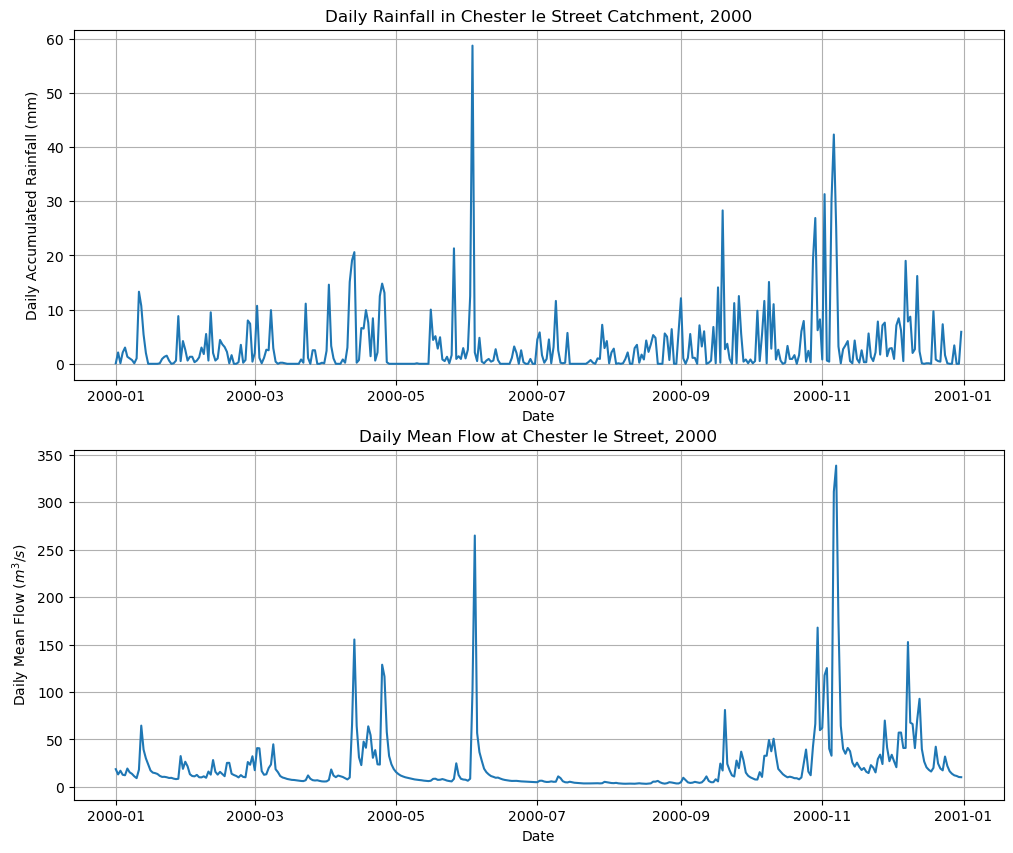

In [34]:
fig, ax  = plt.subplots(2, 1, figsize=(12,10))

# restrict data
START = '2000-01-01'
END = '2000-12-31'
rainfall_restriction = ((rainfall_24009.index >= START) & (rainfall_24009.index <= END))
flow_restriction = ((flow_24009.index >= START) & (flow_24009.index <= END))

# plot rainfall
ax[0].plot(rainfall_24009[rainfall_restriction])
ax[0].set_title('Daily Rainfall in Chester le Street Catchment, 2000')
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Daily Accumulated Rainfall (mm)')
ax[0].grid()

# plot flow
ax[1].plot(flow_24009[flow_restriction])
ax[1].set_title('Daily Mean Flow at Chester le Street, 2000')
ax[1].set_xlabel('Date')
ax[1].set_ylabel(r'Daily Mean Flow ($m^3/s$)')
ax[1].grid()

plt.show()

Initally there appears to be a correlation between rainfall and flow, with large spikes coinciding. However, the largest rainfall (around June) does not coincide with the highest flow (around November). The November flow spike, while coinciding with a spike in rainfall, has a considerably higher amount of rainfall just before. Thus, we will calculate a 3 and 7 day rolling accumulation of rainfall, and once again compare this to flow. 

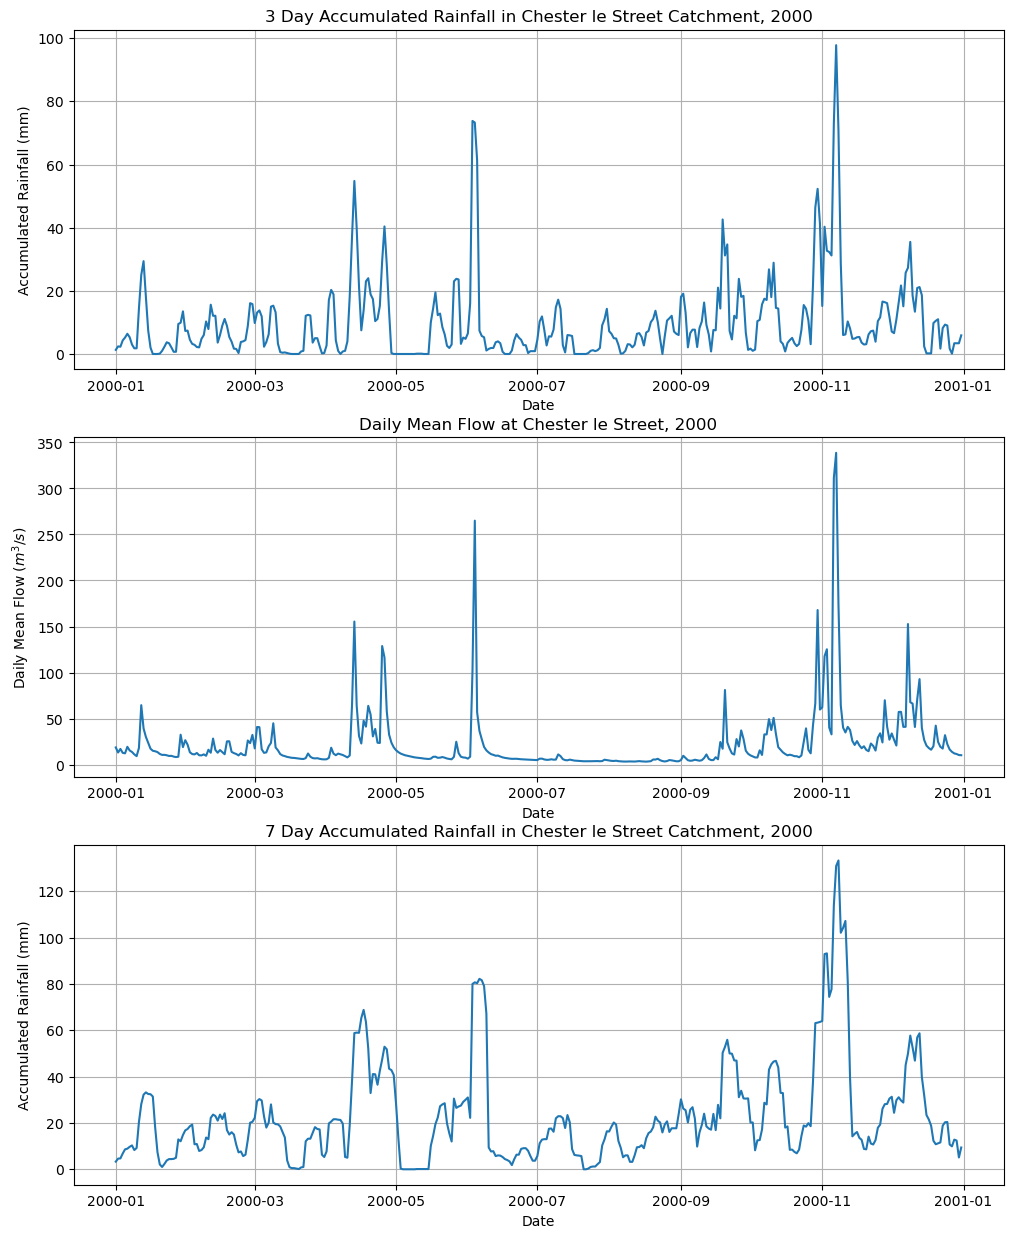

In [35]:
# calculating rolling sums
# copy rainfall data
rainfall_sums_24009 = rainfall_24009.copy()

# calculate 3 and 7 day rolling sums of rainfall
rainfall_sums_24009['3d'] = rainfall_sums_24009['rainfall'].rolling(window=3).sum()
rainfall_sums_24009['7d'] = rainfall_sums_24009['rainfall'].rolling(window=7).sum()

# plot
fig, ax  = plt.subplots(3, 1, figsize=(12,15))

# restrict data
START = '2000-01-01'
END = '2000-12-31'
rainfall_restriction = ((rainfall_sums_24009.index >= START) & (rainfall_sums_24009.index <= END))
flow_restriction = ((flow_24009.index >= START) & (flow_24009.index <= END))

# plot 3d rainfall
ax[0].plot(rainfall_sums_24009.loc[rainfall_restriction, '3d'])
ax[0].set_title('3 Day Accumulated Rainfall in Chester le Street Catchment, 2000')
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Accumulated Rainfall (mm)')
ax[0].grid()

# plot flow
ax[1].plot(flow_24009[flow_restriction])
ax[1].set_title('Daily Mean Flow at Chester le Street, 2000')
ax[1].set_xlabel('Date')
ax[1].set_ylabel(r'Daily Mean Flow ($m^3/s$)')
ax[1].grid()

# plot 7d rainfall
ax[2].plot(rainfall_sums_24009.loc[rainfall_restriction, '7d'])
ax[2].set_title('7 Day Accumulated Rainfall in Chester le Street Catchment, 2000')
ax[2].set_xlabel('Date')
ax[2].set_ylabel('Accumulated Rainfall (mm)')
ax[2].grid()

plt.show()

Notice how much more similar in shape the 3 day accumulation and the flow - visually the correlation between 3 day rainfall accumultion and river flow is much greater. Let us now create a regression plot and quanity the correlation of these variables over all concurrent data for station 24009. 

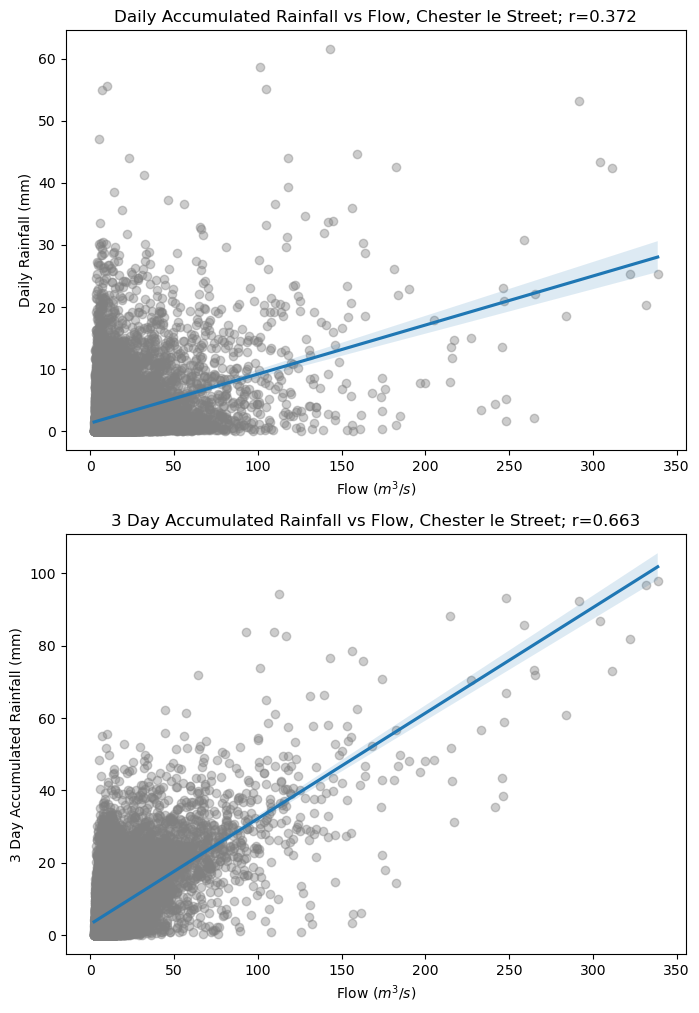

In [36]:
# get combined data on inner join for plotting pariwise points 
rainfall_corr_data_24009 = pd.concat([rainfall_sums_24009[['3d', 'rainfall']], flow_24009], axis=1, join='inner')

# set up plot
fig, ax = plt.subplots(2, 1, figsize=(8,12))

# plot daily accumulation regression
sns.regplot(x='flow', y='rainfall', data=rainfall_corr_data_24009, ax=ax[0],
           scatter_kws={'alpha': 0.4, 'color': 'gray'})

# plot 3 day accumulation
sns.regplot(x='flow', y='3d', data=rainfall_corr_data_24009, ax=ax[1],
           scatter_kws={'alpha': 0.4, 'color': 'gray'})

# calculate correlation coefficients for daily and 3 day accumulation
r_1 = np.corrcoef(rainfall_corr_data_24009['rainfall'], rainfall_corr_data_24009['flow'])[0,1]
r_3 = np.corrcoef(rainfall_corr_data_24009['3d'], rainfall_corr_data_24009['flow'])[0,1]

# label plots; include r value in title
ax[0].set_title(f"Daily Accumulated Rainfall vs Flow, Chester le Street; r={r_1:.3f}")
ax[0].set_xlabel(r"Flow ($m^3/s$)")
ax[0].set_ylabel("Daily Rainfall (mm)")

ax[1].set_title(f"3 Day Accumulated Rainfall vs Flow, Chester le Street; r={r_3:.3f}")
ax[1].set_xlabel(r"Flow ($m^3/s$)")
ax[1].set_ylabel("3 Day Accumulated Rainfall (mm)")

plt.show()

From this we see the 3 day accumulation of rainfall has a much higher linear correlation to river flow (at Chester le Street) both visually and empirically, with respective r-values of 0.663 and 0.372. Intuitively this makes sense, as rainfall does not instantly get to the river (aside from direct rainfall), but has to infiltrate the soil, before moving through surface and subsurface pathways to reach the river. Thus flow reflects the overall 'wetness' rather than just daily rainfall, of which the 3 day accumulation is a much better predictor.

We will recreate the above figure for the rest of the stations, to see if the trend holds for more upstream stations with smaller catchments.

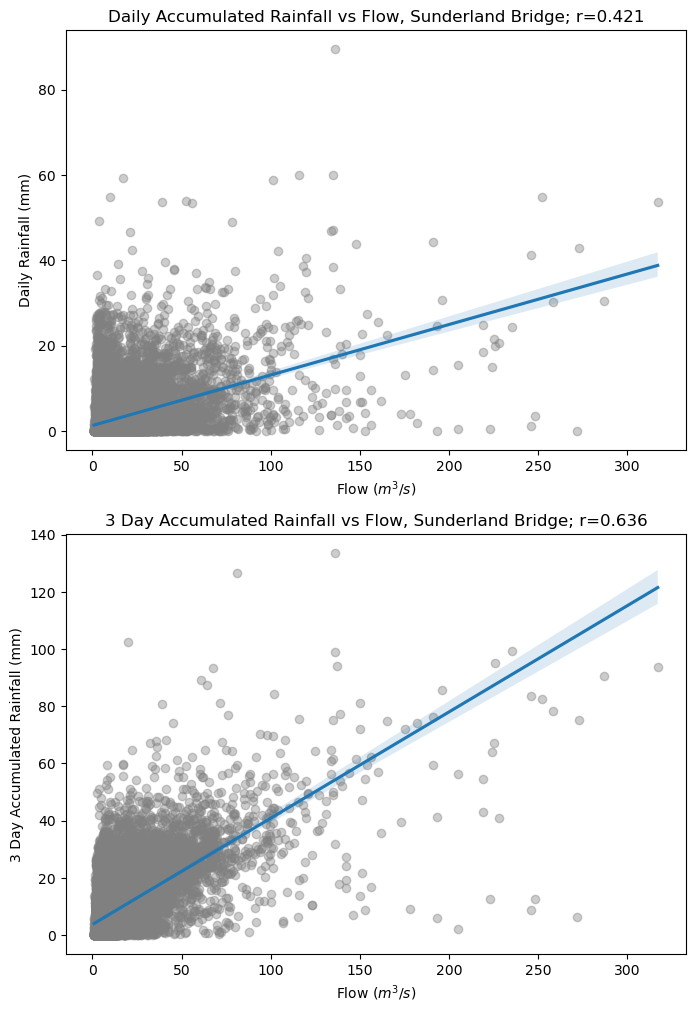

In [37]:
# sunderland bridge - 24001
# find 3 day accumulation
rainfall_sums_24001 = rainfall_24001.copy()
rainfall_sums_24001['3d'] = rainfall_sums_24001['rainfall'].rolling(window=3).sum()

# get combined data on inner join for plotting pariwise points 
rainfall_corr_data_24001 = pd.concat([rainfall_sums_24001, flow_24001], axis=1, join='inner')

# set up plot
fig, ax = plt.subplots(2, 1, figsize=(8,12))

# plot daily accumulation regression
sns.regplot(x='flow', y='rainfall', data=rainfall_corr_data_24001, ax=ax[0],
           scatter_kws={'alpha': 0.4, 'color': 'gray'})

# plot 3 day accumulation
sns.regplot(x='flow', y='3d', data=rainfall_corr_data_24001, ax=ax[1],
           scatter_kws={'alpha': 0.4, 'color': 'gray'})

# calculate correlation coefficients for daily and 3 day accumulation
r_1 = np.corrcoef(rainfall_corr_data_24001['rainfall'], rainfall_corr_data_24001['flow'])[0,1]
r_3 = np.corrcoef(rainfall_corr_data_24001['3d'], rainfall_corr_data_24001['flow'])[0,1]

# label plots; include r value in title
ax[0].set_title(f"Daily Accumulated Rainfall vs Flow, Sunderland Bridge; r={r_1:.3f}")
ax[0].set_xlabel(r"Flow ($m^3/s$)")
ax[0].set_ylabel("Daily Rainfall (mm)")

ax[1].set_title(f"3 Day Accumulated Rainfall vs Flow, Sunderland Bridge; r={r_3:.3f}")
ax[1].set_xlabel(r"Flow ($m^3/s$)")
ax[1].set_ylabel("3 Day Accumulated Rainfall (mm)")

plt.show()

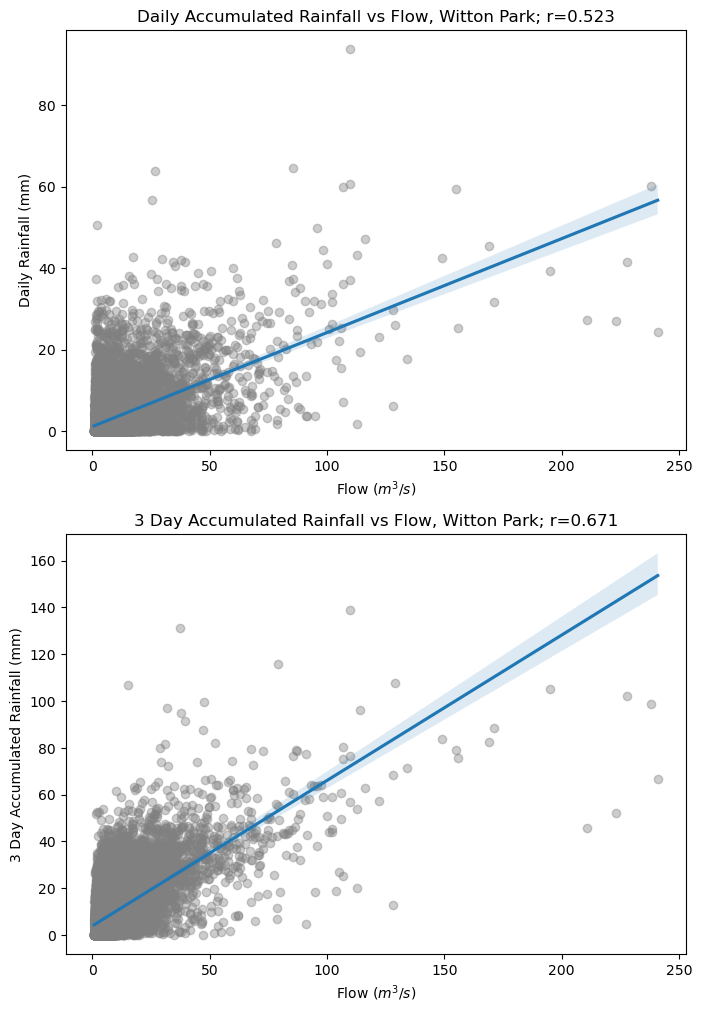

In [38]:
# witton park - 24008
# find 3 day accumulation
rainfall_sums_24008 = rainfall_24008.copy()
rainfall_sums_24008['3d'] = rainfall_sums_24008['rainfall'].rolling(window=3).sum()

# get combined data on inner join for plotting pariwise points 
rainfall_corr_data_24008 = pd.concat([rainfall_sums_24008, flow_24008], axis=1, join='inner')

# set up plot
fig, ax = plt.subplots(2, 1, figsize=(8,12))

# plot daily accumulation regression
sns.regplot(x='flow', y='rainfall', data=rainfall_corr_data_24008, ax=ax[0],
           scatter_kws={'alpha': 0.4, 'color': 'gray'})

# plot 3 day accumulation
sns.regplot(x='flow', y='3d', data=rainfall_corr_data_24008, ax=ax[1],
           scatter_kws={'alpha': 0.4, 'color': 'gray'})

# calculate correlation coefficients for daily and 3 day accumulation
r_1 = np.corrcoef(rainfall_corr_data_24008['rainfall'], rainfall_corr_data_24008['flow'])[0,1]
r_3 = np.corrcoef(rainfall_corr_data_24008['3d'], rainfall_corr_data_24008['flow'])[0,1]

# label plots; include r value in title
ax[0].set_title(f"Daily Accumulated Rainfall vs Flow, Witton Park; r={r_1:.3f}")
ax[0].set_xlabel(r"Flow ($m^3/s$)")
ax[0].set_ylabel("Daily Rainfall (mm)")

ax[1].set_title(f"3 Day Accumulated Rainfall vs Flow, Witton Park; r={r_3:.3f}")
ax[1].set_xlabel(r"Flow ($m^3/s$)")
ax[1].set_ylabel("3 Day Accumulated Rainfall (mm)")

plt.show()

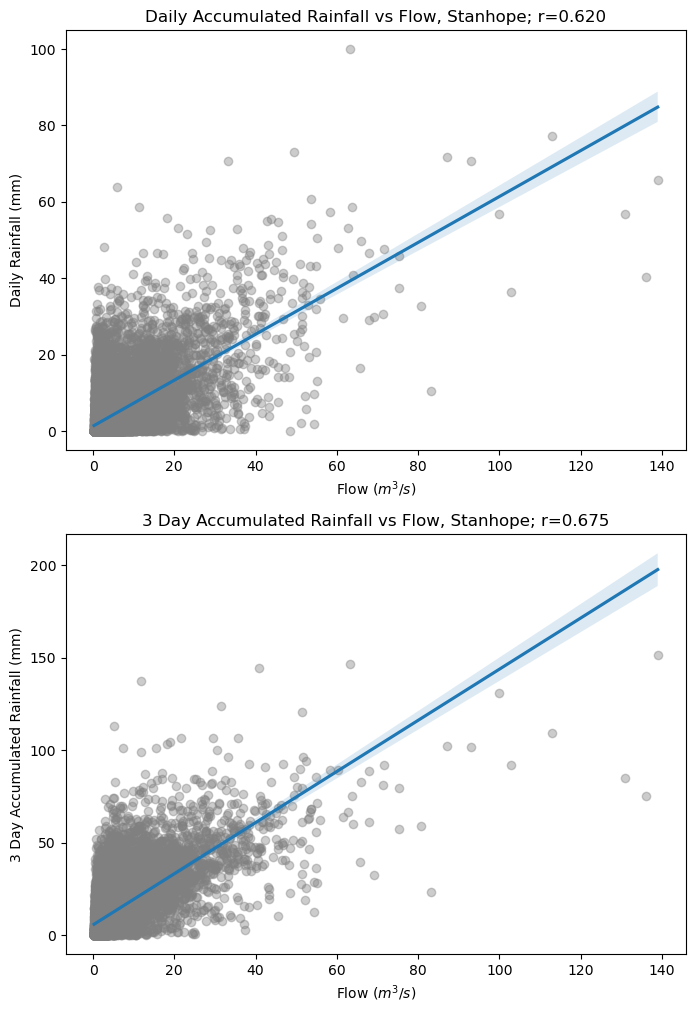

In [39]:
# stanhope - 24003
# find 3 day accumulation
rainfall_sums_24003 = rainfall_24003.copy()
rainfall_sums_24003['3d'] = rainfall_sums_24003['rainfall'].rolling(window=3).sum()

# get combined data on inner join for plotting pariwise points 
rainfall_corr_data_24003 = pd.concat([rainfall_sums_24003, flow_24003], axis=1, join='inner')

# set up plot
fig, ax = plt.subplots(2, 1, figsize=(8,12))

# plot daily accumulation regression
sns.regplot(x='flow', y='rainfall', data=rainfall_corr_data_24003, ax=ax[0],
           scatter_kws={'alpha': 0.4, 'color': 'gray'})

# plot 3 day accumulation
sns.regplot(x='flow', y='3d', data=rainfall_corr_data_24003, ax=ax[1],
           scatter_kws={'alpha': 0.4, 'color': 'gray'})

# calculate correlation coefficients for daily and 3 day accumulation
r_1 = np.corrcoef(rainfall_corr_data_24003['rainfall'], rainfall_corr_data_24003['flow'])[0,1]
r_3 = np.corrcoef(rainfall_corr_data_24003['3d'], rainfall_corr_data_24003['flow'])[0,1]

# label plots; include r value in title
ax[0].set_title(f"Daily Accumulated Rainfall vs Flow, Stanhope; r={r_1:.3f}")
ax[0].set_xlabel(r"Flow ($m^3/s$)")
ax[0].set_ylabel("Daily Rainfall (mm)")

ax[1].set_title(f"3 Day Accumulated Rainfall vs Flow, Stanhope; r={r_3:.3f}")
ax[1].set_xlabel(r"Flow ($m^3/s$)")
ax[1].set_ylabel("3 Day Accumulated Rainfall (mm)")

plt.show()

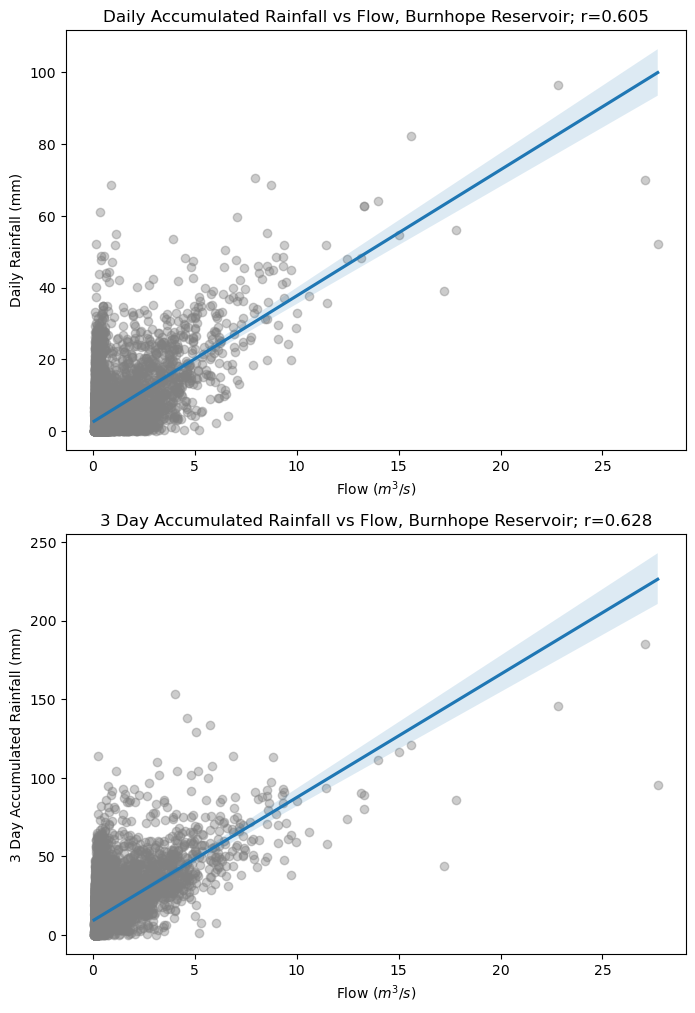

In [40]:
# burnhope resovoir - 24011
# find 3 day accumulation
rainfall_sums_24011 = rainfall_24011.copy()
rainfall_sums_24011['3d'] = rainfall_sums_24011['rainfall'].rolling(window=3).sum()

# get combined data on inner join for plotting pariwise points 
rainfall_corr_data_24011 = pd.concat([rainfall_sums_24011, flow_24011], axis=1, join='inner')

# set up plot
fig, ax = plt.subplots(2, 1, figsize=(8,12))

# plot daily accumulation regression
sns.regplot(x='flow', y='rainfall', data=rainfall_corr_data_24011, ax=ax[0],
           scatter_kws={'alpha': 0.4, 'color': 'gray'})

# plot 3 day accumulation
sns.regplot(x='flow', y='3d', data=rainfall_corr_data_24011, ax=ax[1],
           scatter_kws={'alpha': 0.4, 'color': 'gray'})

# calculate correlation coefficients for daily and 3 day accumulation
r_1 = np.corrcoef(rainfall_corr_data_24011['rainfall'], rainfall_corr_data_24011['flow'])[0,1]
r_3 = np.corrcoef(rainfall_corr_data_24011['3d'], rainfall_corr_data_24011['flow'])[0,1]

# label plots; include r value in title
ax[0].set_title(f"Daily Accumulated Rainfall vs Flow, Burnhope Reservoir; r={r_1:.3f}")
ax[0].set_xlabel(r"Flow ($m^3/s$)")
ax[0].set_ylabel("Daily Rainfall (mm)")

ax[1].set_title(f"3 Day Accumulated Rainfall vs Flow, Burnhope Reservoir; r={r_3:.3f}")
ax[1].set_xlabel(r"Flow ($m^3/s$)")
ax[1].set_ylabel("3 Day Accumulated Rainfall (mm)")

plt.show()

From these plots, we see that the trend holds, with higher correlation between the 3 day accumulated rainfall and river flow, compared to the daily rainfall. However, as the catchment size decreases upstream, the daily rainfall correlation rises, while the 3 day accumulations remains relatively constant, and the gap between r-values for both narrows, with a difference of only 0.023 at Burnhope Reservoir, the most upstream guage with the smallest catchment. Physically this still makes sense, as the smaller catchment means it takes less time for rainfall to find its way to the river, thus the daily and 3 day accumulation have more similar effect on river flow.

## Section 3 [Advanced, 18 marks]: 

- Come up with your own question relating to the river flow, catchment, and rainfall data.
    - You may use any rivers you like.
    - You may include other data, but this is not required to get a high mark.
    - It must be more than simply repeating the analysis from the earlier sections for a different river.
- Write down your question and explain what you expect to find, or what possibilities you are testing.
- Outline your analysis approach. What data will you need? What will you calculate? What will you plot? This is just your initial plan. Do not edit it as you go along – you will note your changing ideas and plans as you go.
- Do your analysis. After each section of analysis, write down your interpretation of the results and if it changes your ideas about the river behaviour or your plans for further analysis.
- End with a short summary of what you have learnt and some ideas for further work.

I am very interested by the flow at Burnhope Reservoir, specifically the flat bottom and square looking cycles which we hypothesised earlier were caused by human control of the dam and overfullness in winter. I want to investigate this, looking at how much the dam controls the river, compared to how much the weather control the river. I believe this could be achieved with use of Fourier Analysis, specifcally power spectra to isolate dominant frequencies. I would expect there to be large support for the compensation rate, a statutory minimum flow required of the reservoir to maintain river flow in dry periods. Below we outline full analysis process:

**Research Question:** How is the flow at Burnhope Reservoir affected by constant human regulation compared to natural climate variability?

**Hypothesis:** The flow is dominated by human control (via the resovoir dam).

**Methods of Analysis:**
* Timeseries plots - identify the features we want to quanitfy; check for long term trends; set expectations for base flow and period of cycles
* Statistical Calculations:
  * Mean and Median
  * Standard Deviation and skew- measure variability in the data
* Fourier Analysis:
  * Fast Fourier Transformation - decompose data into frequencies
  * Power Specturm Analysis - show dominance of each frequency to quantify influence; expect to see a spike at zero for base flow, and 1 for the annual summer/winter cycle

Note also that the Burnhope Resovoir flow data does not have any interpolated values, so all evidence is robust. We begin now by looking at timerseires plots for flow at Burnhope Reservoir.

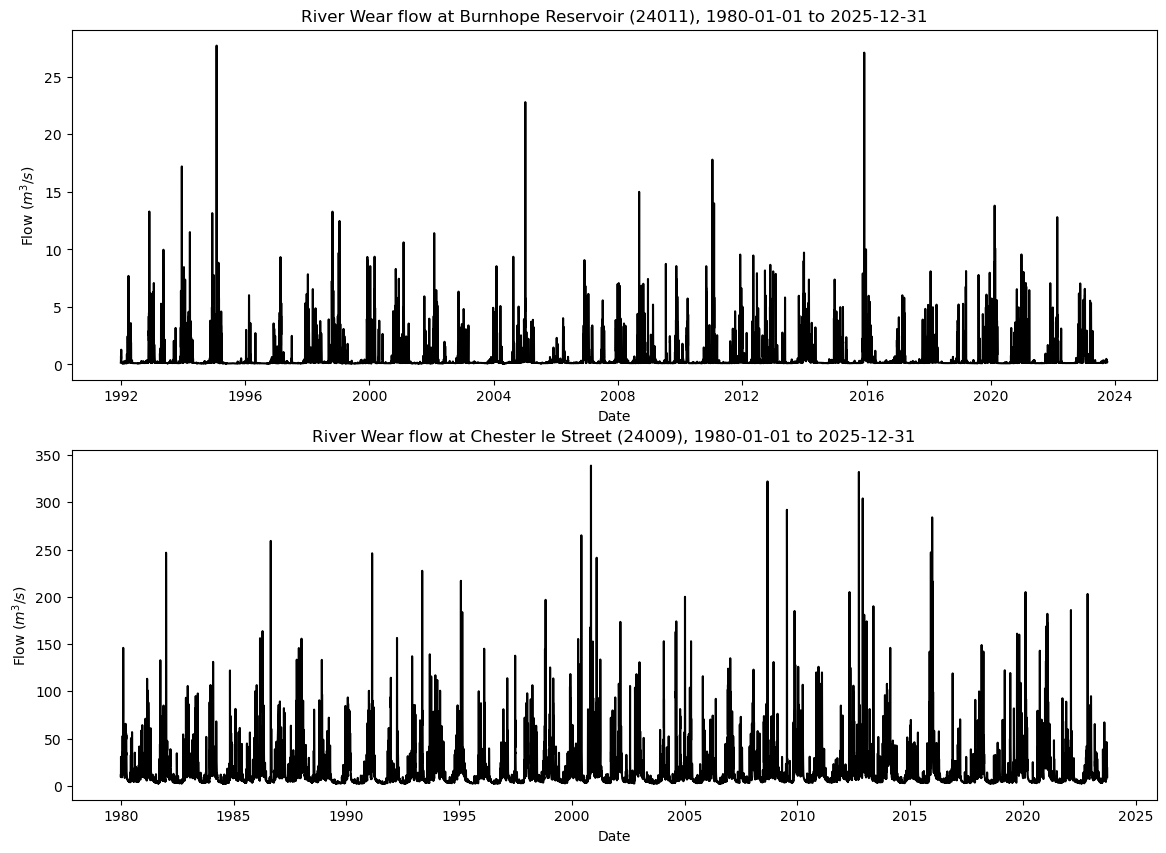

In [41]:
# plot 2015-2020
# create mask to restrict timeframe
START_DATE = '1980-01-01'
END_DATE = '2025-12-31'
time_restriction_11 = ((flow_24011.index >= START_DATE) & (flow_24011.index <= END_DATE))
time_restriction_9 = ((flow_24009.index >= START_DATE) & (flow_24009.index <= END_DATE))

# get data for plotting
plot_data_11 = flow_24011.loc[time_restriction_11]
plot_data_9 = flow_24009.loc[time_restriction_9]

# set up plot
fig, ax = plt.subplots(2, 1, figsize=(14,10)) 

# plot flow timeseries at Burnhope
ax[0].plot(plot_data_11.index, plot_data_11['flow'], color='black')
# add labels
ax[0].set_title(f'River Wear flow at Burnhope Reservoir (24011), {START_DATE} to {END_DATE}')
ax[0].set_ylabel(r'Flow ($m^3/s$)')
ax[0].set_xlabel('Date')

# plot flow at chester le street
ax[1].plot(plot_data_9.index, plot_data_9['flow'], color='black')
# add labels
ax[1].set_title(f'River Wear flow at Chester le Street (24009), {START_DATE} to {END_DATE}')
ax[1].set_ylabel(r'Flow ($m^3/s$)')
ax[1].set_xlabel('Date')

plt.show()

As expected, we see that flow at Burnhope Reservoir has a flat bottom compared to downstream (Chester le Street) where the flow is on a more continuos cycle. Both exhibit large peaks of flow (likely winter storms as we saw rainfall is positively correlated to flow). We also notice there appears to be no long term trend in Burnhope flow, as it returns to the same values year on year. Let us now 'zoom into' the Burnhope to make estimates on base rate flow and periods. 

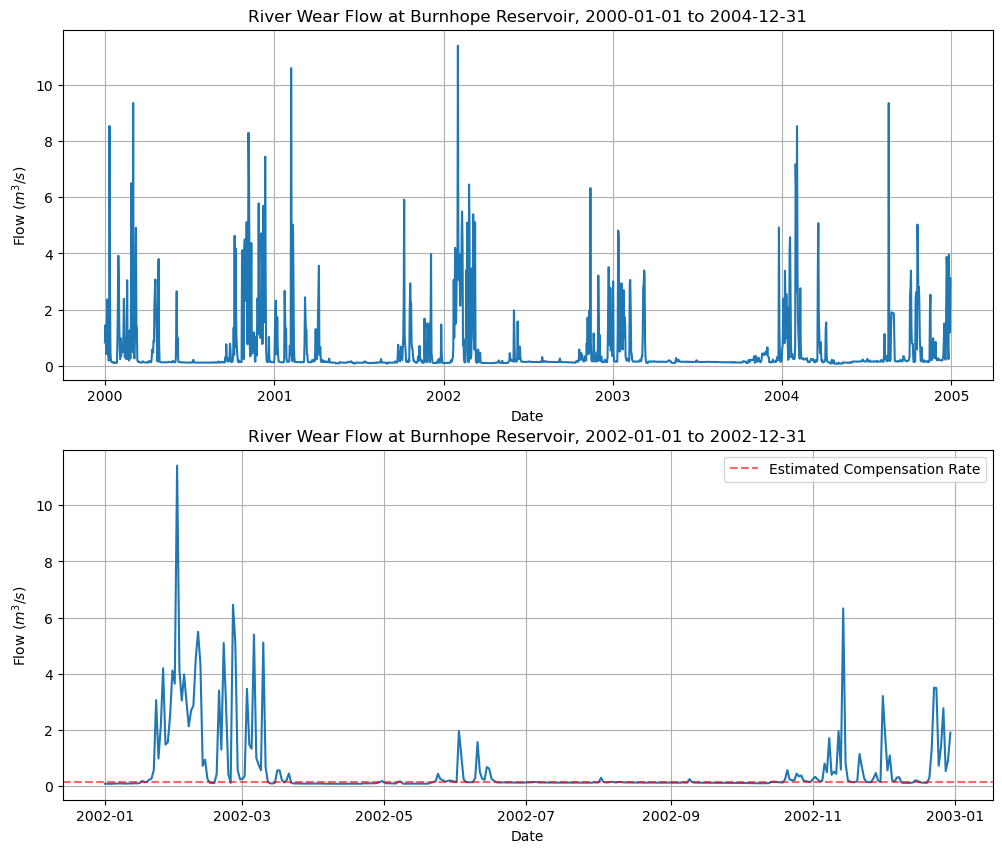

In [42]:
# set up plot
fig, ax = plt.subplots(2, 1, figsize=(12,10))

# first date restriction - wider
START_DATE_1 = '2000-01-01'
END_DATE_1 = '2004-12-31'
time_restriction_1 = (flow_24011.index >= START_DATE_1) & (flow_24011.index < END_DATE_1)

# plot wider restriction data
ax[0].plot(flow_24011[time_restriction_1])
# add labels
ax[0].set_title(f'River Wear Flow at Burnhope Reservoir, {START_DATE_1} to {END_DATE_1}')
ax[0].set_ylabel(r'Flow ($m^3/s$)')
ax[0].set_xlabel('Date')
ax[0].grid()

# second date destriction - narrow
START_DATE_2 = '2002-01-01'
END_DATE_2 = '2002-12-31'
time_restriction_2 = (flow_24011.index >= START_DATE_2) & (flow_24011.index < END_DATE_2)

# plot narrower restriction
ax[1].plot(flow_24011[time_restriction_2])
# add labels
ax[1].set_title(f'River Wear Flow at Burnhope Reservoir, {START_DATE_2} to {END_DATE_2}')
ax[1].set_ylabel(r'Flow ($m^3/s$)')
ax[1].set_xlabel('Date')
ax[1].grid()
ax[1].axhline(0.15, color='red', alpha=0.6, linestyle='--', label='Estimated Compensation Rate')

plt.legend()
plt.show()

Zooming in to a 5 year period (2000-2005) and a 1 year period (2002), we can estimate that the cycle appears repeat annually, with clusters of spikes over winter and low periods in summer. We do notice some spikes in the low perdiods, likely to be summer storms, and we will expect those to come up as low power, higher freuency spikes in the power spectrum later. We can also see that the the low is held at a constant, non-zero level, which we can estimate to be around $0.15 m^3/s$.

We not calculate summary statistics, giving more insight into data, and also required in prepartion of FFT.

In [43]:
# look first at flow description - gives basic descriptive statistics
print(flow_24011.describe())

               flow
count  11596.000000
mean       0.572319
std        1.279869
min        0.055000
25%        0.118000
50%        0.141000
75%        0.282000
max       27.710000


We see that the mean is a lot higher than our estimated value for base compensation flow, which we hypothesised to dominate. Note however that the standard deviation is high, meaning the mean is likely highly skewed by the large releases in winter. Looking at the median and IQR, we see that it is tight around 0.14, very close to our estimation of 0.15. We will see how this distirbtuion compares to that of downstream flow at Cherter le Street. We will normalise the values using the mean so we can compare on the same scale.  

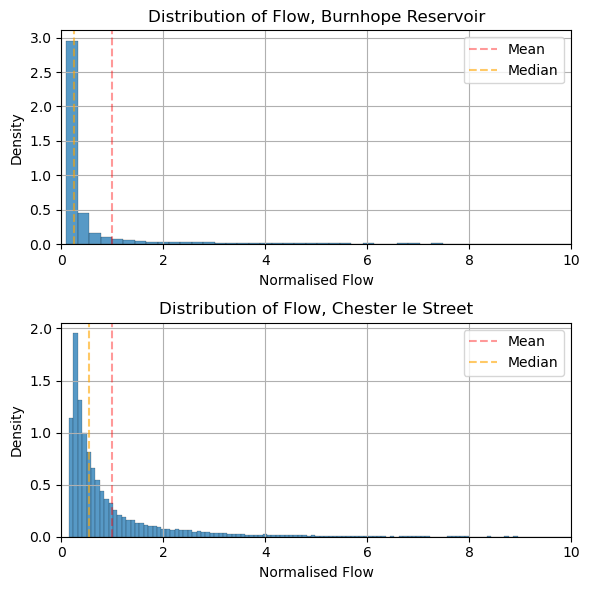

In [44]:
# set up plot
fig, ax = plt.subplots(2,1, figsize=(6, 6))

# plot density histograms, normalised by mean
sns.histplot(flow_24011['flow']/np.mean(flow_24011['flow']), ax=ax[0], stat='density')
sns.histplot(flow_24009['flow']/np.mean(flow_24009['flow']), ax=ax[1], stat='density')

# set x lims as we are unconcerned about the tail
ax[0].set_xlim(0,10)
# plot line at mean
ax[0].axvline(1, label='Mean', color='red', alpha=0.4, linestyle='--')
# plot line at median
ax[0].axvline(np.median(flow_24011['flow']/np.mean(flow_24011['flow'])), label='Median', color='orange', alpha=0.6, linestyle='--')
# add labels
ax[0].set_title('Distribution of Flow, Burnhope Reservoir')
ax[0].set_xlabel('Normalised Flow')
ax[0].grid()
ax[0].legend()

# set x lims as we are unconcerned about the tail
ax[1].set_xlim(0,10)
# plot line at mean
ax[1].axvline(1, label='Mean', color='red', alpha=0.4, linestyle='--')
# plot line at median
ax[1].axvline(np.median(flow_24009['flow']/np.mean(flow_24009['flow'])), label='Median', color='orange', alpha=0.6, linestyle='--')
# add labels
ax[1].set_title('Distribution of Flow, Chester le Street')
ax[1].set_xlabel('Normalised Flow')
ax[1].grid()
ax[1].legend()

plt.tight_layout()
plt.show()

Upon observation, flow at the Reservoir exhibits a very large positive skew. Downstream, the distibution is still skewed, but the density is 4 times lower at lower flows, and the median lies far closer to the mean. This is further evidence of irregular flow near the reservoir, likely caused by human intervention.

We now find the fourier series that represents this data for Burnhope Reservoir by use of a Fast Fourier Trasform (FFT). Using the appropriate numpy library, we calculate the coefficients, frequency and power of frequencies of the flow data. 

In [45]:
# get coefficients for fft of data
fft_coefficients = np.fft.fft(flow_24011['flow'])

# get corresponding frequencies; d=1 to get spacing in years (our data is daily intervals)
fft_freq = np.fft.fftfreq(len(flow_24011['flow']), d=1/365)

# get power associated with each coefficients
fft_power = np.abs(fft_coefficients)

We now plot the power spectrum to see yearly cycles. 

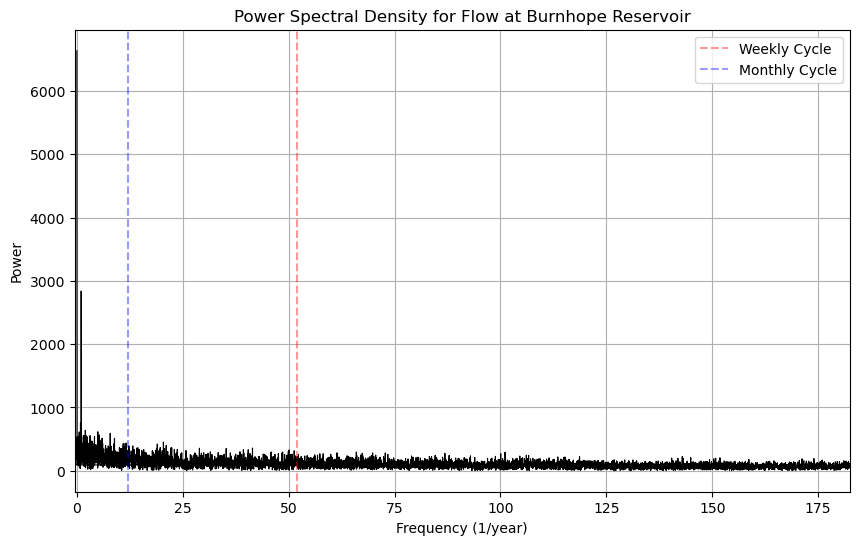

In [46]:
# plot power spectra
plt.figure(figsize=(10,6))
plt.plot(fft_freq, fft_power, color='black', lw=0.8)

# set limit to only show positive frequencies (symmetrical)
plt.xlim(-0.5,fft_freq.max())

# plot lines at weeks (52) and months (7)
plt.axvline(52, alpha=0.4, color='red', label='Weekly Cycle', linestyle='--')
plt.axvline(12, alpha=0.4, color='blue', label='Monthly Cycle', linestyle='--')

# add labels
plt.xlabel('Frequency (1/year)')
plt.ylabel('Power')
plt.title('Power Spectral Density for Flow at Burnhope Reservoir')

plt.legend()
plt.grid()
plt.show()

As we can see there are two large spikes in the power spectrum, occuring at 0 and 1. The spike at 0 represents the offset, an unchanging amount throughout the year. This is our compensation flow. The other large spike occurs at a frequency of 1. This is a cycle that happens once a year - likely the difference between summer (dry) and winter (wet). There are no other large spikes in the data, meaning no other cycles are as powerful. We plotted weekly cycles (52 per year) and monthy cycles (12 per year) and do not observe spikes at these locations. If spikes did exist in these locations, it would indicate regular, periodic release from the reservoir but this is not the case. Finally, we see that the power of the 0 frequency spike is over double that of the 1 frequency spike, giving us empirical evidence that the reservoir signicantly controls river flow.

To conclude, testing our hypothesis through graphical analysis and statistical measures including fourier analysis, we prove it to be true - the human control via the Burnhope Resevoir does dominate the control of flow of the River Wear.

To further this study, we could include meterological data, for temperature or precipitation, and see how it coincides with spikes. Another area to look at could be at the reservoir operation, what protocols are taken in overfull or drought periods, and if this can explain anomlaous events. 